# Stage 1 & 2 Analysis

**Project:** Does Daylight Saving Time Reduce Property Crime?  
**Course:** IDS 701 — Problem Solving with Data Science, Duke University, Spring 2026  
**Design:** California (treated, observes DST) vs Arizona (control, never observes DST)  


---

## a) How Data Is Accessed and Processed

**Stage 1 (daily, 1A):** Loaded directly from two raw CSVs:
- `data/processed/crime/focus_states_daily_county_counts.csv` — one row per state × county × date × crime type
- `data/processed/population/focus_states_county_population_2020_2024_long.csv` — county populations by year

We aggregate daily counts to the **state level**, merge state-year population, and compute `rate_per_100k`. Restricted to CA and AZ; Navajo Nation AZ counties excluded via the `proposal_excluded_az_county` flag.

**Stage 1 (hourly, 1B–1D):** Loaded from the pre-structured hourly file:
- `data/processed/crime/focus_states_hourly_structured.csv` — one row per state × county_fips × date × hour × offense type

Filtered to CA and AZ (NV excluded). A **±28-day symmetric window** around the 2024 spring-forward (2024-03-10) is used — this is the only spring-forward event covered by hourly data.

**Stage 2 (daily panel):** Loaded from the pre-built model panel:
- `data/processed/model/focus_states_daily_county_model_panel_2022_2024.csv` — one row per county_fips × date × crime type, already merged with population, ACS socioeconomic variables, weather, and DST flags

Filtered to: CA counties where `observes_dst_county == True` (treated) and AZ counties where `is_az_control == True` and `observes_dst_county == False` (Navajo Nation excluded). FL and UT rows are dropped entirely.

---

## b) How New Variables Are Created

| Variable | How created |
|---|---|
| `rate_per_100k` | `incident_count / population * 100_000` (state-level for 1A) |
| `crime_rate_per_100k` | Pre-computed in panel: `incident_count / county_population * 100_000` |
| `log_rate` | `np.log1p(crime_rate_per_100k)` — log(1 + rate) to handle zeros |
| `post_dst` | `(date >= DST_SPRING_2024).astype(int)` — 1 on/after 2024-03-10 |
| `days_from_dst` | `(date - DST_SPRING_2024).dt.days` — signed days relative to spring-forward |
| `treated_state` | `(state == 'CA').astype(int)` — 1 for California, 0 for Arizona |
| `time_bucket` | Hour mapped to 4 buckets: `morning_dark` (5–8h), `daytime` (9–17h), `evening_light` (18–21h), `late_night` (0–4h, 22–23h) |
| `in_dst_window` | Pre-computed in panel: 1 for CA during spring-forward through fall-back, 0 for AZ year-round |
| `days_from_dst_start` | Pre-computed in panel: signed days relative to spring-forward for each year |
| `year_month` | `incident_date.dt.to_period('M').astype(str)` — used as time FE identifier in TWFE |
| `data_year` | `incident_date.dt.year` |
| `group` | String label: `'California (treated)'` or `'Arizona (control)'` |

---

### Notebook Structure

| Section | Content |
|---|---|
| 0 | Setup |
| 1A | Daily seasonality (CA vs AZ) and ±15-day spring-forward window |
| 1B | Hourly crime profile before vs. after spring-forward |
| 1C | Time-of-day bucket summary |
| 1D | Displacement regression (within-state + triple-difference) |
| 2.1 | Load panel and build estimation sample (CA + AZ only) |
| 2.2 | Monthly crime rate trends |
| 2.3 | Pre-trends visual |
| 2.4 | Main TWFE DiD |
| 2.5 | Event study (spring-forward + fall-back) |
| 2.6 | Narrow-window check |
| 2.7 | Robustness checks |
| 2.8 | Summary |

## Section 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ── Find project root ────────────────────────────────────────────────────
_root = Path.cwd()
for _ in range(4):
    if (_root / 'data').exists() and (_root / 'scripts').exists():
        break
    _root = _root.parent
os.chdir(_root)

# ── Plot style (matches stage1/stage2 notebooks) ─────────────────────────
mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# ── Constants ────────────────────────────────────────────────────────────
CRIMES       = ['burglary', 'motor_vehicle_theft']
CRIME_LABELS = {'burglary': 'Burglary', 'motor_vehicle_theft': 'Motor Vehicle Theft'}
STATE_COLORS = {'CA': '#1f77b4', 'AZ': '#d62728'}
YEAR_STYLES  = {2022: ('--', 0.40), 2023: (':', 0.40), 2024: ('-.', 0.40)}
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# ── DST transition dates ─────────────────────────────────────────────────
def spring_forward(year):
    d0 = date(year, 3, 1)
    return d0 + timedelta(days=(6 - d0.weekday()) % 7) + timedelta(days=7)

def fall_back(year):
    d0 = date(year, 11, 1)
    return d0 + timedelta(days=(6 - d0.weekday()) % 7)

DST_DATES = {y: {'start': spring_forward(y), 'end': fall_back(y)} for y in [2022, 2023, 2024]}
DST_SPRING_2024 = pd.Timestamp('2024-03-10')   # for hourly window

# ── File paths ────────────────────────────────────────────────────────────
DAILY_PATH   = Path('data/processed/crime/focus_states_daily_county_counts.csv')
POP_PATH     = Path('data/processed/population/focus_states_county_population_2020_2024_long.csv')
HOURLY_PATH  = Path('data/processed/crime/focus_states_hourly_structured.csv')
PANEL_PATH   = Path('data/processed/model/focus_states_daily_county_model_panel_2022_2024.csv')

print('Working dir:', Path.cwd())
print('DST transition dates:')
for y, d in DST_DATES.items():
    print(f'  {y}: spring-forward={d["start"]}  fall-back={d["end"]}')
print('\nFile availability:')
for p in [DAILY_PATH, POP_PATH, HOURLY_PATH, PANEL_PATH]:
    print(f'  {p.name}: {"OK" if p.exists() else "MISSING"}')

Working dir: /Users/shellyy/Desktop/IDS_701/IDS701_UDS_Final_Project
DST transition dates:
  2022: spring-forward=2022-03-13  fall-back=2022-11-06
  2023: spring-forward=2023-03-12  fall-back=2023-11-05
  2024: spring-forward=2024-03-10  fall-back=2024-11-03

File availability:
  focus_states_daily_county_counts.csv: OK
  focus_states_county_population_2020_2024_long.csv: OK
  focus_states_hourly_structured.csv: OK
  focus_states_daily_county_model_panel_2022_2024.csv: OK


## Section 1A — Daily Data: Seasonality and Spring-Forward Window

**Source:** `focus_states_daily_county_counts.csv` + population file.  
**Processing:** Aggregate daily counts to state level, merge state-year population, compute `rate_per_100k`.  
**Plot 1 (top):** Average daily rate by calendar month — shows both CA and AZ peak in summer regardless of DST.  
**Plot 2 (bottom):** ±15-day window around spring-forward — if DST caused a crime level shift, CA should jump at day 0 but AZ should not.

In [2]:
from matplotlib.lines import Line2D

# ── Load daily crime and population data ─────────────────────────────────
daily = pd.read_csv(DAILY_PATH, parse_dates=['incident_date'])
pop   = pd.read_csv(POP_PATH)
pop['data_year'] = pop['data_year'].astype(int)

# Exclude Navajo Nation AZ counties using the flag in the population file
excl    = pop['proposal_excluded_az_county'].fillna(False)
pop_use = pd.concat([pop[pop['state'] != 'AZ'], pop[(pop['state'] == 'AZ') & (~excl)]], ignore_index=True)
st_pop  = pop_use.groupby(['state', 'data_year'], as_index=False)['population'].sum()

# Filter to CA, AZ, UT; target crimes; 2022-2024
PLOT_STATES = ['CA', 'AZ', 'UT']
d = daily[
    daily['state'].isin(PLOT_STATES) &
    daily['crime_type'].isin(CRIMES) &
    daily['incident_date'].dt.year.between(2022, 2024)
].copy()
d['year'] = d['incident_date'].dt.year.astype(int)

# Aggregate to state level and compute rate
st_day = (
    d.groupby(['state', 'year', 'incident_date', 'crime_type'], as_index=False)['incident_count'].sum()
     .merge(st_pop.rename(columns={'data_year': 'year'}), on=['state', 'year'], how='left')
)
st_day['rate_per_100k'] = st_day['incident_count'] / st_day['population'] * 100_000.0
st_day['month']         = st_day['incident_date'].dt.month

# Spring-forward dates as Timestamps (for bottom-row window plot)
sf_dates = {y: pd.Timestamp(DST_DATES[y]['start']) for y in [2022, 2023, 2024]}
def days_from_sf(row):
    return (row['incident_date'] - sf_dates[row['year']]).days
st_day['days_from_sf'] = st_day.apply(days_from_sf, axis=1)

# Month ordering: Non-DST (Nov–Feb) on left, DST (Mar–Oct) on right
MONTH_ORDER  = [11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
MONTH_XLABELS = ['Nov','Dec','Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct']
month_to_x   = {m: i for i, m in enumerate(MONTH_ORDER)}
st_day['x_pos'] = st_day['month'].map(month_to_x)

# State colors — add UT
STATE_COLORS_3 = {'CA': '#1f77b4', 'AZ': '#d62728', 'UT': '#2ca02c'}

print(f'State-day rows: {len(st_day):,}')
print(f'States: {sorted(st_day["state"].unique())}')
print(f'Years:  {sorted(st_day["year"].unique())}')

State-day rows: 6,576
States: ['AZ', 'CA', 'UT']
Years:  [np.int64(2022), np.int64(2023), np.int64(2024)]


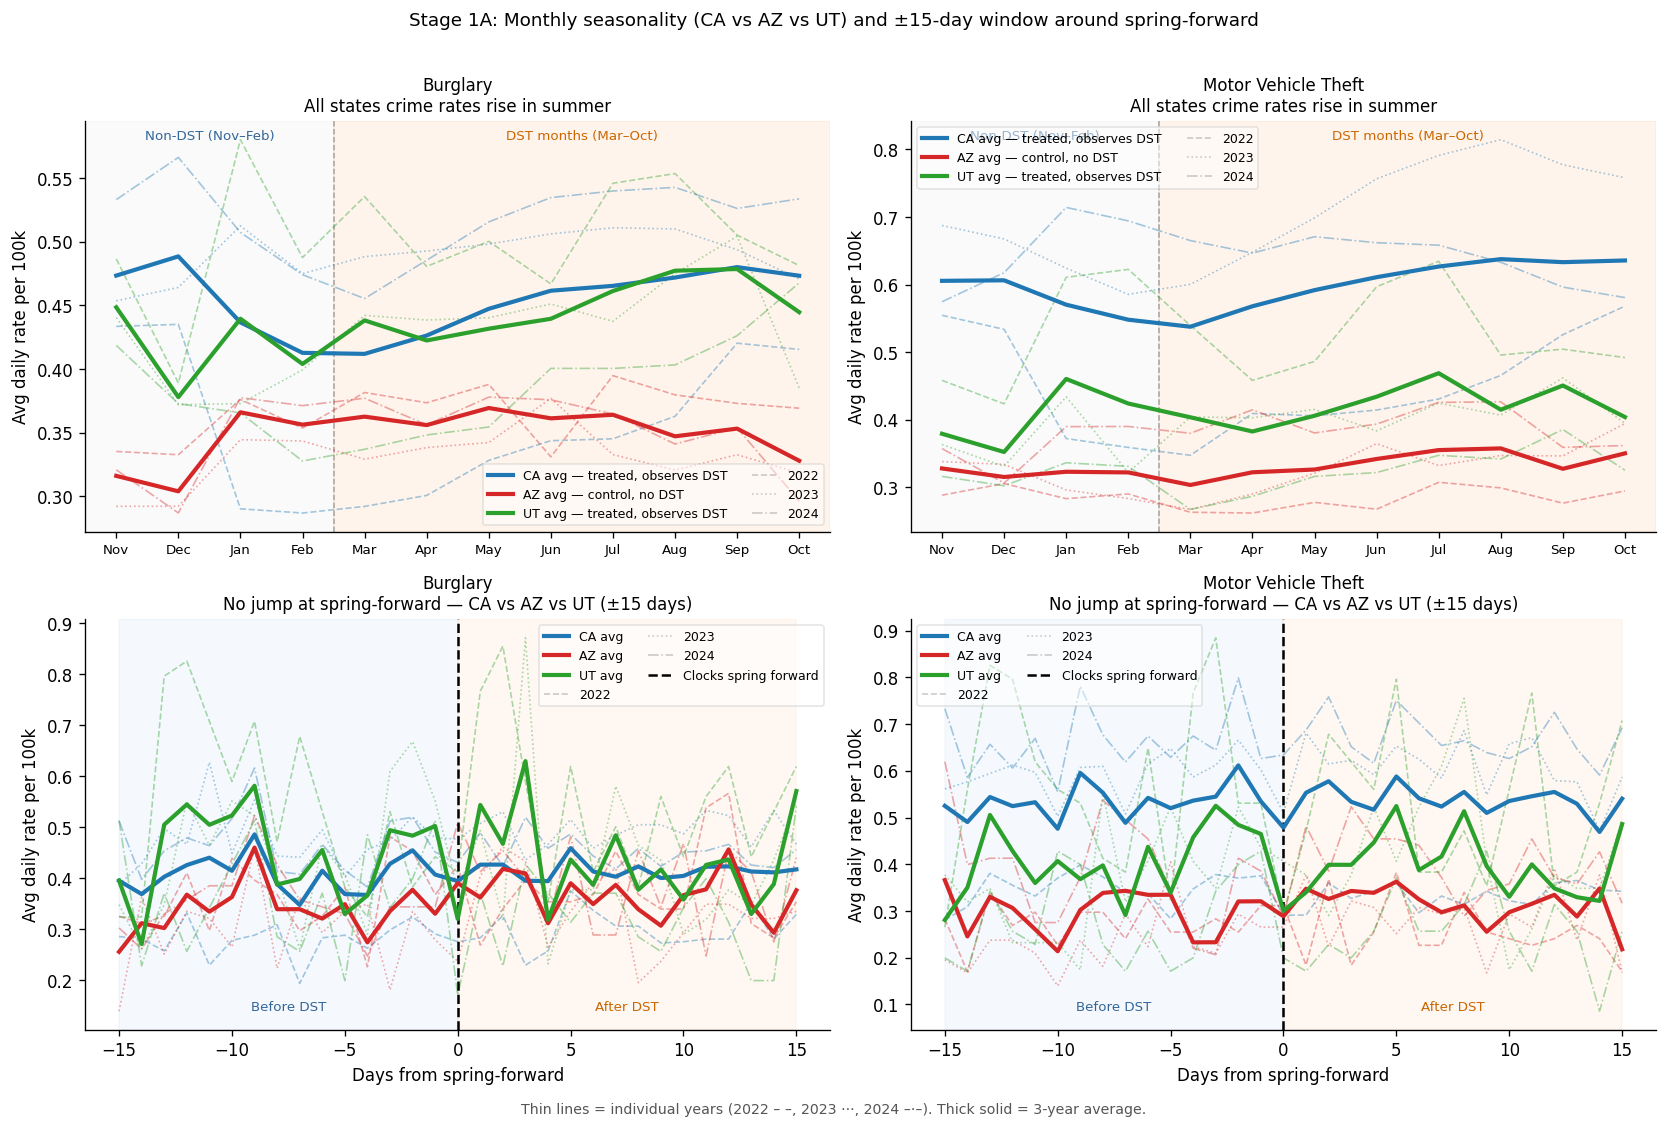

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Stage 1A: Monthly seasonality (CA vs AZ vs UT) and ±15-day window around spring-forward',
    fontsize=11, y=1.01,
)

STATE_LINE_LABELS = {
    'CA': 'CA avg — treated, observes DST',
    'AZ': 'AZ avg — control, no DST',
    'UT': 'UT avg — treated, observes DST',
}

for col, crime in enumerate(CRIMES):
    sub = st_day[st_day['crime_type'] == crime].copy()

    # ── TOP ROW: monthly avg daily rate (Nov–Oct ordering) ───────────────
    ax = axes[0][col]
    ax.axvspan(-0.5,  3.5, alpha=0.10, color='lightgray', zorder=0)
    ax.axvspan( 3.5, 11.5, alpha=0.08, color='#ff7f0e',   zorder=0)
    ax.axvline(3.5, color='gray', lw=0.9, ls='--', alpha=0.7)
    ax.text(1.5, 0.98, 'Non-DST (Nov–Feb)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#336699', ha='center', va='top')
    ax.text(7.5, 0.98, 'DST months (Mar–Oct)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#cc6600', ha='center', va='top')

    # Individual year lines (thin)
    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_sub = (sub[(sub['state'] == state) & (sub['year'] == year)]
                      .groupby('x_pos')['rate_per_100k'].mean().reset_index()
                      .sort_values('x_pos'))
            ax.plot(yr_sub['x_pos'], yr_sub['rate_per_100k'],
                    color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2)

    # 3-year average (thick solid)
    avg = sub.groupby(['state', 'x_pos'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = avg[avg['state'] == state].sort_values('x_pos')
        ax.plot(s['x_pos'], s['rate_per_100k'],
                color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3)

    ax.set_title(f'{CRIME_LABELS[crime]}\nAll states crime rates rise in summer', fontsize=10)
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_XLABELS, fontsize=8)
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylabel('Avg daily rate per 100k')

    # Split legend: state colors + year dash styles
    state_h = [Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
                      label=STATE_LINE_LABELS[s]) for s in PLOT_STATES]
    year_h  = [Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
                      label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()]
    ax.legend(handles=state_h + year_h, fontsize=7.5, framealpha=0.5, ncol=2)

    # ── BOTTOM ROW: ±15-day spring-forward window ─────────────────────────
    ax2 = axes[1][col]
    win_sub = sub[sub['days_from_sf'].between(-15, 15)].copy()

    # Individual year lines (thin, no band)
    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_win = (win_sub[(win_sub['state'] == state) & (win_sub['year'] == year)]
                      .groupby('days_from_sf')['rate_per_100k'].mean().reset_index()
                      .sort_values('days_from_sf'))
            ax2.plot(yr_win['days_from_sf'], yr_win['rate_per_100k'],
                     color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2)

    # 3-year average (thick solid, no band)
    win_avg = win_sub.groupby(['state', 'days_from_sf'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = win_avg[win_avg['state'] == state].sort_values('days_from_sf')
        ax2.plot(s['days_from_sf'], s['rate_per_100k'],
                 color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3)

    ax2.axvline(0, color='black', lw=1.5, ls='--')
    ax2.axvspan(-15, 0, alpha=0.05, color='#4a90d9')
    ax2.axvspan(  0, 15, alpha=0.05, color='#ff7f0e')
    ax2.text(-7.5, 0.04, 'Before DST', transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#336699', ha='center', va='bottom')
    ax2.text( 7.5, 0.04, 'After DST',  transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#cc6600', ha='center', va='bottom')
    ax2.set_title(f'{CRIME_LABELS[crime]}\nNo jump at spring-forward — CA vs AZ vs UT (±15 days)', fontsize=10)
    ax2.set_xlabel('Days from spring-forward')
    ax2.set_ylabel('Avg daily rate per 100k')

    # Split legend: state colors + year dash styles + vertical line marker
    state_h2 = [Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
                       label=f'{s} avg') for s in PLOT_STATES]
    year_h2  = [Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
                       label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()]
    clock_h  = [Line2D([0],[0], color='black', lw=1.5, ls='--', label='Clocks spring forward')]
    ax2.legend(handles=state_h2 + year_h2 + clock_h, fontsize=7.5, framealpha=0.5, ncol=2)

fig.text(0.5, -0.01,
         'Thin lines = individual years (2022 – –, 2023 ···, 2024 –·–). Thick solid = 3-year average.',
         ha='center', fontsize=8.5, color='#555')
plt.tight_layout()
plt.show()

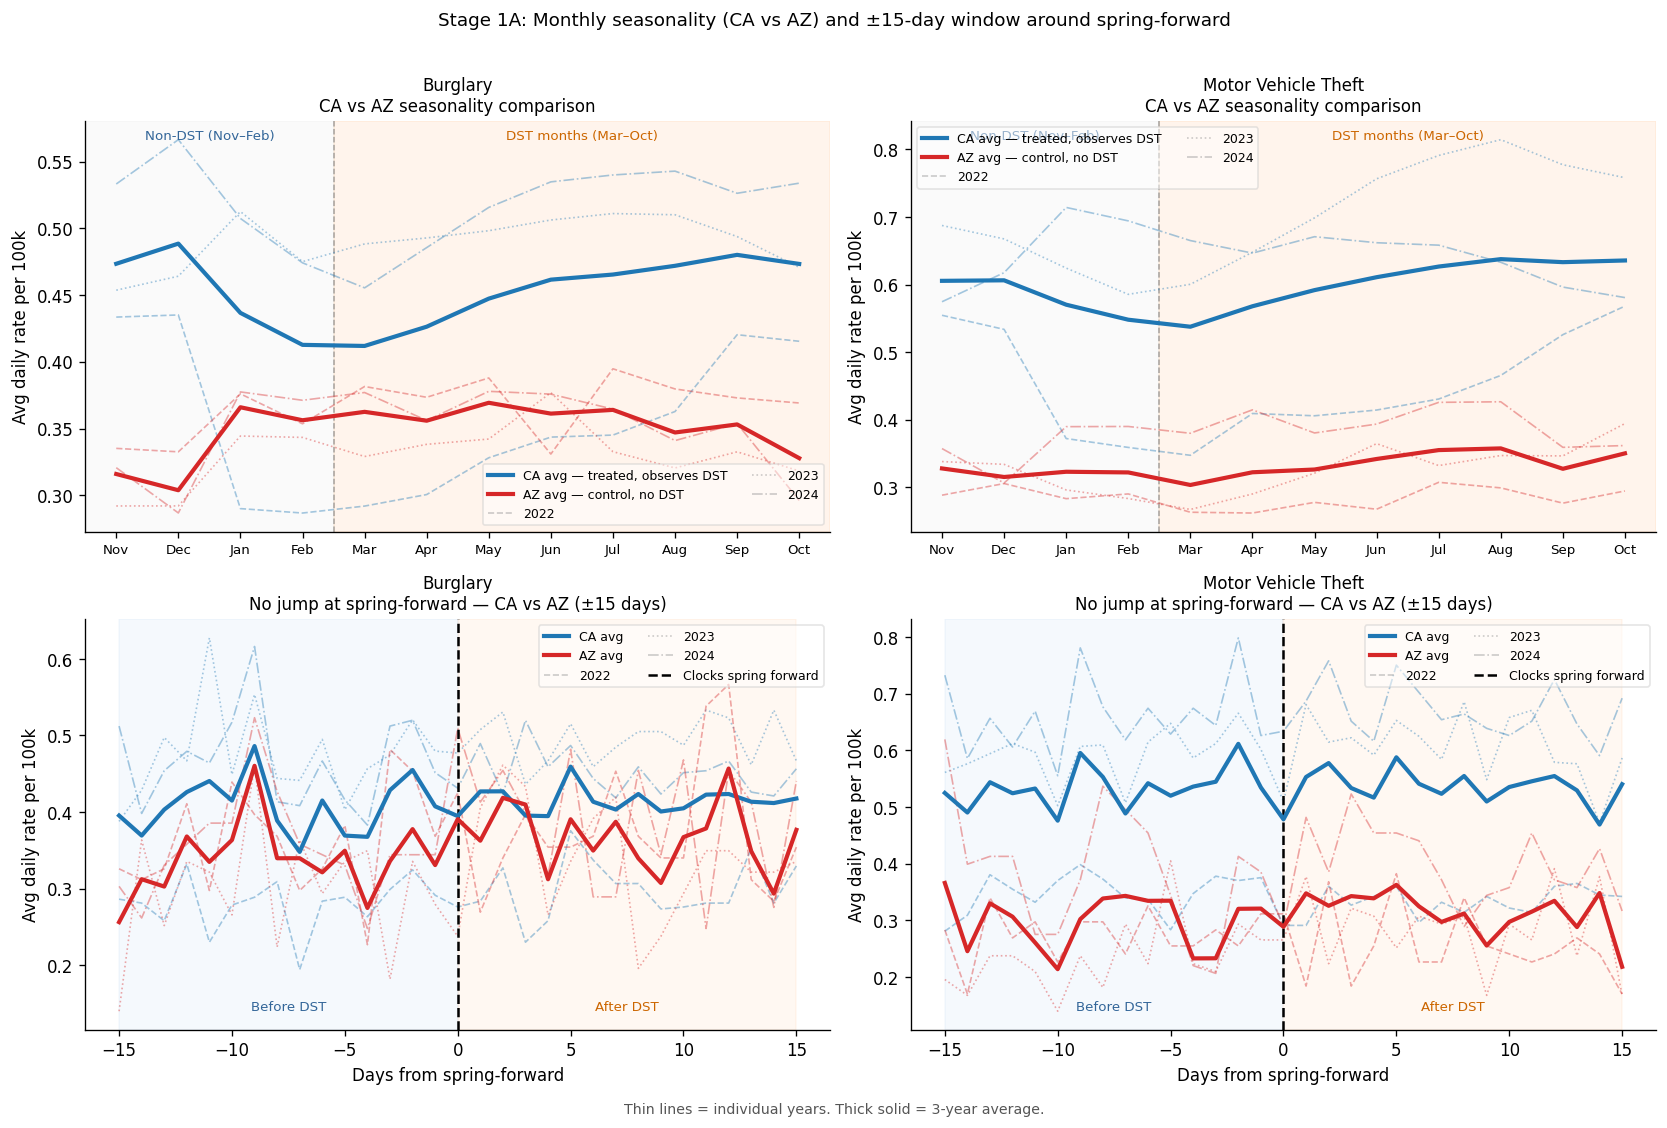

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Stage 1A: Monthly seasonality (CA vs AZ) and ±15-day window around spring-forward',
    fontsize=11, y=1.01,
)

# --- REMOVE UT HERE ---
STATE_LINE_LABELS = {
    'CA': 'CA avg — treated, observes DST',
    'AZ': 'AZ avg — control, no DST',
}

# Only keep CA and AZ
PLOT_STATES = ['CA', 'AZ']

for col, crime in enumerate(CRIMES):
    sub = st_day[st_day['crime_type'] == crime].copy()

    # ── TOP ROW ─────────────────────────────────────────────
    ax = axes[0][col]
    ax.axvspan(-0.5,  3.5, alpha=0.10, color='lightgray', zorder=0)
    ax.axvspan( 3.5, 11.5, alpha=0.08, color='#ff7f0e', zorder=0)
    ax.axvline(3.5, color='gray', lw=0.9, ls='--', alpha=0.7)

    ax.text(1.5, 0.98, 'Non-DST (Nov–Feb)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#336699', ha='center', va='top')
    ax.text(7.5, 0.98, 'DST months (Mar–Oct)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#cc6600', ha='center', va='top')

    # Individual year lines
    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_sub = (
                sub[(sub['state'] == state) & (sub['year'] == year)]
                .groupby('x_pos')['rate_per_100k']
                .mean()
                .reset_index()
                .sort_values('x_pos')
            )
            ax.plot(
                yr_sub['x_pos'], yr_sub['rate_per_100k'],
                color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2
            )

    # 3-year average
    avg = sub.groupby(['state', 'x_pos'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = avg[avg['state'] == state].sort_values('x_pos')
        ax.plot(
            s['x_pos'], s['rate_per_100k'],
            color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3
        )

    ax.set_title(f'{CRIME_LABELS[crime]}\nCA vs AZ seasonality comparison', fontsize=10)
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_XLABELS, fontsize=8)
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylabel('Avg daily rate per 100k')

    # Legend
    state_h = [
        Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
               label=STATE_LINE_LABELS[s]) for s in PLOT_STATES
    ]
    year_h  = [
        Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
               label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()
    ]
    ax.legend(handles=state_h + year_h, fontsize=7.5, framealpha=0.5, ncol=2)

    # ── BOTTOM ROW ─────────────────────────────────────────
    ax2 = axes[1][col]
    win_sub = sub[sub['days_from_sf'].between(-15, 15)].copy()

    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_win = (
                win_sub[(win_sub['state'] == state) & (win_sub['year'] == year)]
                .groupby('days_from_sf')['rate_per_100k']
                .mean()
                .reset_index()
                .sort_values('days_from_sf')
            )
            ax2.plot(
                yr_win['days_from_sf'], yr_win['rate_per_100k'],
                color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2
            )

    win_avg = win_sub.groupby(['state', 'days_from_sf'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = win_avg[win_avg['state'] == state].sort_values('days_from_sf')
        ax2.plot(
            s['days_from_sf'], s['rate_per_100k'],
            color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3
        )

    ax2.axvline(0, color='black', lw=1.5, ls='--')
    ax2.axvspan(-15, 0, alpha=0.05, color='#4a90d9')
    ax2.axvspan(0, 15, alpha=0.05, color='#ff7f0e')

    ax2.text(-7.5, 0.04, 'Before DST', transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#336699', ha='center', va='bottom')
    ax2.text(7.5, 0.04, 'After DST', transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#cc6600', ha='center', va='bottom')

    ax2.set_title(f'{CRIME_LABELS[crime]}\nNo jump at spring-forward — CA vs AZ (±15 days)', fontsize=10)
    ax2.set_xlabel('Days from spring-forward')
    ax2.set_ylabel('Avg daily rate per 100k')

    state_h2 = [
        Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
               label=f'{s} avg') for s in PLOT_STATES
    ]
    year_h2  = [
        Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
               label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()
    ]
    clock_h  = [Line2D([0],[0], color='black', lw=1.5, ls='--',
                       label='Clocks spring forward')]

    ax2.legend(handles=state_h2 + year_h2 + clock_h,
               fontsize=7.5, framealpha=0.5, ncol=2)

fig.text(
    0.5, -0.01,
    'Thin lines = individual years. Thick solid = 3-year average.',
    ha='center', fontsize=8.5, color='#555'
)

plt.tight_layout()
plt.show()

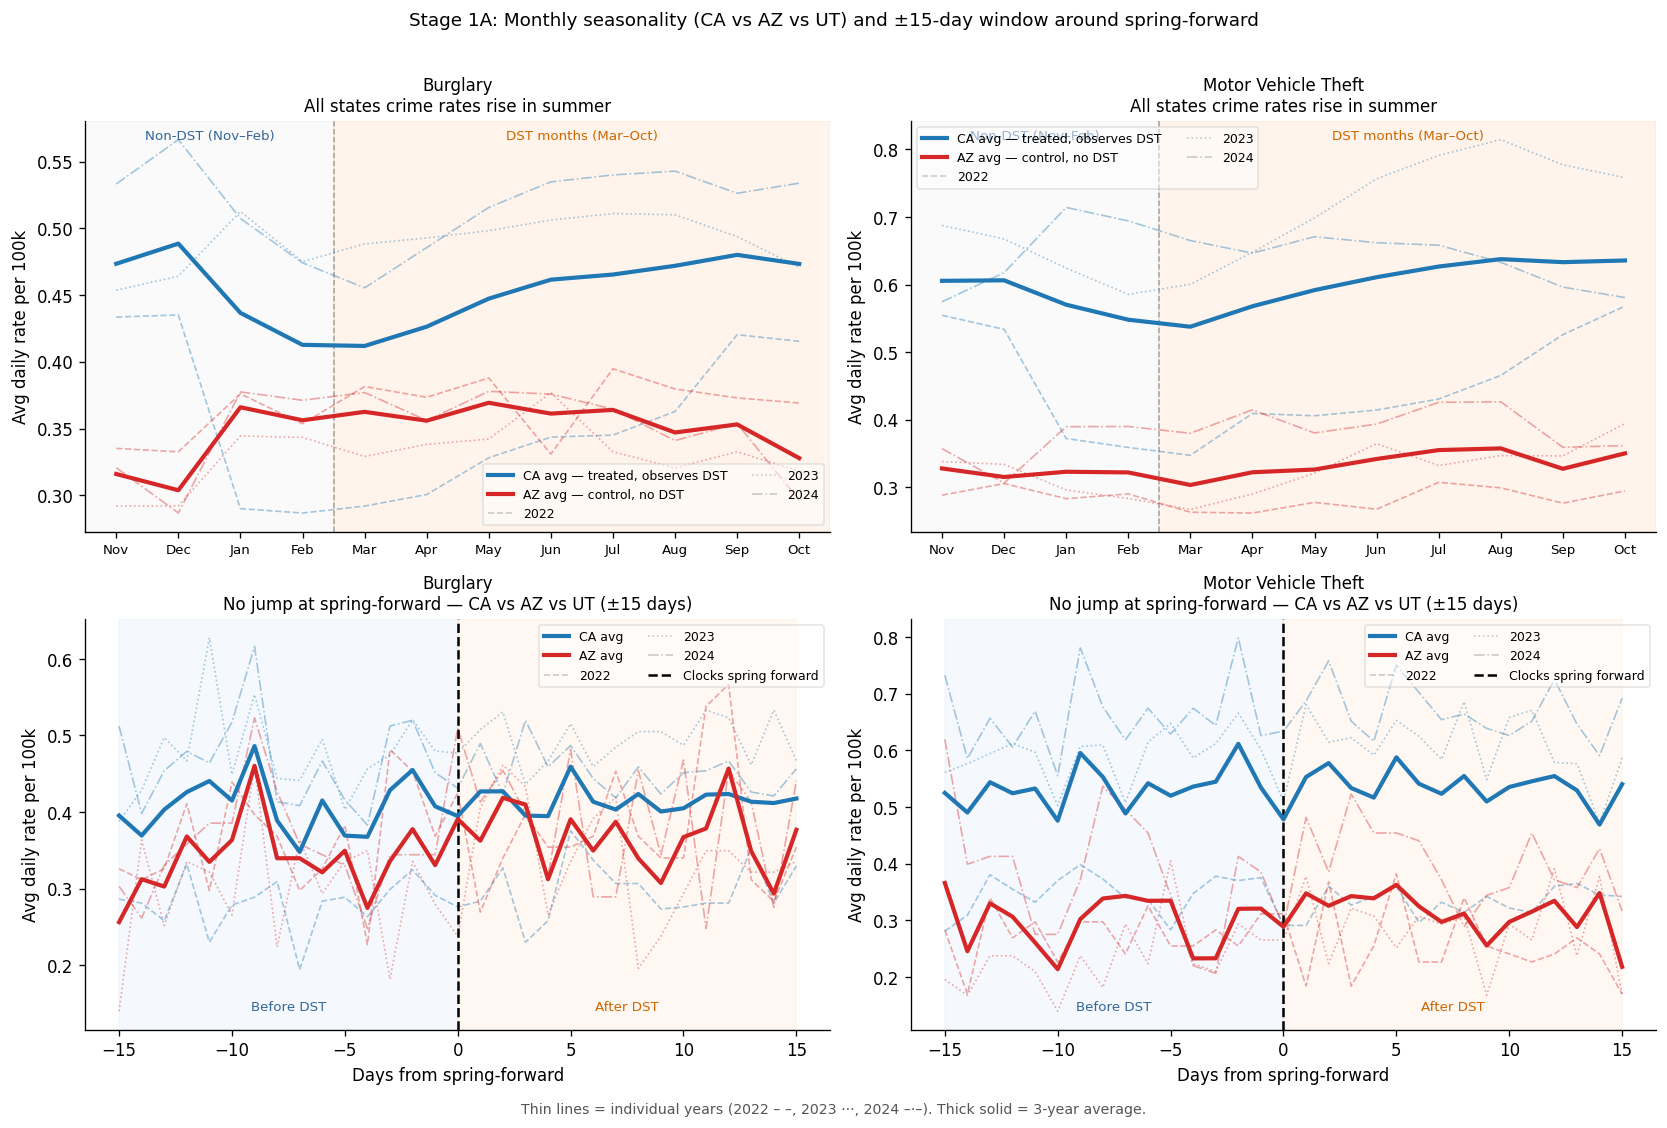

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Stage 1A: Monthly seasonality (CA vs AZ vs UT) and ±15-day window around spring-forward',
    fontsize=11, y=1.01,
)

STATE_LINE_LABELS = {
    'CA': 'CA avg — treated, observes DST',
    'AZ': 'AZ avg — control, no DST',
    'UT': 'UT avg — treated, observes DST',
}

for col, crime in enumerate(CRIMES):
    sub = st_day[st_day['crime_type'] == crime].copy()

    # ── TOP ROW: monthly avg daily rate (Nov–Oct ordering) ───────────────
    ax = axes[0][col]
    ax.axvspan(-0.5,  3.5, alpha=0.10, color='lightgray', zorder=0)
    ax.axvspan( 3.5, 11.5, alpha=0.08, color='#ff7f0e',   zorder=0)
    ax.axvline(3.5, color='gray', lw=0.9, ls='--', alpha=0.7)
    ax.text(1.5, 0.98, 'Non-DST (Nov–Feb)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#336699', ha='center', va='top')
    ax.text(7.5, 0.98, 'DST months (Mar–Oct)', transform=ax.get_xaxis_transform(),
            fontsize=8, color='#cc6600', ha='center', va='top')

    # Individual year lines (thin)
    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_sub = (sub[(sub['state'] == state) & (sub['year'] == year)]
                      .groupby('x_pos')['rate_per_100k'].mean().reset_index()
                      .sort_values('x_pos'))
            ax.plot(yr_sub['x_pos'], yr_sub['rate_per_100k'],
                    color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2)

    # 3-year average (thick solid)
    avg = sub.groupby(['state', 'x_pos'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = avg[avg['state'] == state].sort_values('x_pos')
        ax.plot(s['x_pos'], s['rate_per_100k'],
                color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3)

    ax.set_title(f'{CRIME_LABELS[crime]}\nAll states crime rates rise in summer', fontsize=10)
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_XLABELS, fontsize=8)
    ax.set_xlim(-0.5, 11.5)
    ax.set_ylabel('Avg daily rate per 100k')

    # Split legend: state colors + year dash styles
    state_h = [Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
                      label=STATE_LINE_LABELS[s]) for s in PLOT_STATES]
    year_h  = [Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
                      label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()]
    ax.legend(handles=state_h + year_h, fontsize=7.5, framealpha=0.5, ncol=2)

    # ── BOTTOM ROW: ±15-day spring-forward window ─────────────────────────
    ax2 = axes[1][col]
    win_sub = sub[sub['days_from_sf'].between(-15, 15)].copy()

    # Individual year lines (thin, no band)
    for state in PLOT_STATES:
        color = STATE_COLORS_3[state]
        for year, (ls, alpha) in YEAR_STYLES.items():
            yr_win = (win_sub[(win_sub['state'] == state) & (win_sub['year'] == year)]
                      .groupby('days_from_sf')['rate_per_100k'].mean().reset_index()
                      .sort_values('days_from_sf'))
            ax2.plot(yr_win['days_from_sf'], yr_win['rate_per_100k'],
                     color=color, lw=1.0, linestyle=ls, alpha=alpha, zorder=2)

    # 3-year average (thick solid, no band)
    win_avg = win_sub.groupby(['state', 'days_from_sf'])['rate_per_100k'].mean().reset_index()
    for state in PLOT_STATES:
        s = win_avg[win_avg['state'] == state].sort_values('days_from_sf')
        ax2.plot(s['days_from_sf'], s['rate_per_100k'],
                 color=STATE_COLORS_3[state], lw=2.5, linestyle='-', zorder=3)

    ax2.axvline(0, color='black', lw=1.5, ls='--')
    ax2.axvspan(-15, 0, alpha=0.05, color='#4a90d9')
    ax2.axvspan(  0, 15, alpha=0.05, color='#ff7f0e')
    ax2.text(-7.5, 0.04, 'Before DST', transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#336699', ha='center', va='bottom')
    ax2.text( 7.5, 0.04, 'After DST',  transform=ax2.get_xaxis_transform(),
             fontsize=8, color='#cc6600', ha='center', va='bottom')
    ax2.set_title(f'{CRIME_LABELS[crime]}\nNo jump at spring-forward — CA vs AZ vs UT (±15 days)', fontsize=10)
    ax2.set_xlabel('Days from spring-forward')
    ax2.set_ylabel('Avg daily rate per 100k')

    # Split legend: state colors + year dash styles + vertical line marker
    state_h2 = [Line2D([0],[0], color=STATE_COLORS_3[s], lw=2.5, ls='-',
                       label=f'{s} avg') for s in PLOT_STATES]
    year_h2  = [Line2D([0],[0], color='gray', lw=1.0, ls=ls, alpha=alpha,
                       label=str(y)) for y, (ls, alpha) in YEAR_STYLES.items()]
    clock_h  = [Line2D([0],[0], color='black', lw=1.5, ls='--', label='Clocks spring forward')]
    ax2.legend(handles=state_h2 + year_h2 + clock_h, fontsize=7.5, framealpha=0.5, ncol=2)

fig.text(0.5, -0.01,
         'Thin lines = individual years (2022 – –, 2023 ···, 2024 –·–). Thick solid = 3-year average.',
         ha='center', fontsize=8.5, color='#555')
plt.tight_layout()
plt.show()

## Section 1B — Hourly Crime Profile Before vs. After Spring-Forward

**Source:** `focus_states_hourly_structured.csv` — filtered to **CA + UT (treated)** and **AZ (control)** only.  
**Window:** ±28 days around 2024-03-10 (the only year with full hourly coverage).  

**New variables created here:**
- `date`: reconstructed from year/month/day columns
- `post_dst`: 1 on/after 2024-03-10, 0 before
- `days_from_dst`: signed days relative to spring-forward
- `treated_state`: 1 for CA or UT, 0 for AZ
- `time_bucket`: maps each hour to one of four light-regime buckets

**Plot:** Average hourly crime count by hour — post-DST (orange) vs. pre-DST (dark). Left panel = treated (CA+UT), right = AZ control. If the daylight mechanism works, the evening bucket (18–21h) should shrink and morning (5–8h) should grow in the treated panel after spring-forward.

In [6]:
# ── Load hourly data, filter to CA, UT (treated) and AZ (control) ────────
_raw = pd.read_csv(HOURLY_PATH, low_memory=False)
_raw = _raw[_raw['state'].isin(['CA', 'UT', 'AZ'])].copy()

TREATED_STATES = ['CA', 'UT']

# Reconstruct date from year/month/day columns
df_h = _raw.assign(
    date=lambda d: pd.to_datetime(d[['year', 'month', 'day']]),
).assign(
    post_dst=lambda d: (d['date'] >= DST_SPRING_2024).astype(int),
    days_from_dst=lambda d: (d['date'] - DST_SPRING_2024).dt.days,
    day_of_week=lambda d: d['date'].dt.dayofweek,
    treated_state=lambda d: d['state'].isin(TREATED_STATES).astype(int),
)

# ±28-day window around spring-forward
WINDOW_DAYS = 28
win = df_h[df_h['days_from_dst'].between(-WINDOW_DAYS, WINDOW_DAYS)].copy()

# Time-of-day buckets (light-regime motivated)
# morning_dark (5–8h):   sunrise ~1h later after spring-forward → darker mornings
# daytime (9–17h):       light regardless of DST (regression reference)
# evening_light (18–21h):sunset ~1h later after spring-forward → lighter evenings
# late_night (0–4h, 22–23h): dark regardless
BUCKET_DEF = {
    'morning_dark':  range(5, 9),
    'daytime':       range(9, 18),
    'evening_light': range(18, 22),
    'late_night':    list(range(0, 5)) + list(range(22, 24)),
}
hour_to_bucket = {h: b for b, hrs in BUCKET_DEF.items() for h in hrs}
win['time_bucket'] = win['hour'].map(hour_to_bucket)

n_treated = win[win['treated_state'] == 1]['county_fips'].nunique()
n_control = win[win['treated_state'] == 0]['county_fips'].nunique()
print(f'Window: {win["date"].min().date()} to {win["date"].max().date()}')
print(f'Treated states (CA+UT): {sorted(win[win["treated_state"]==1]["state"].unique())}')
print(f'Treated counties: {n_treated}')
print(f'Control counties (AZ): {n_control}')
print(f'Rows in window: {len(win):,}')

Window: 2024-02-11 to 2024-04-07
Treated states (CA+UT): ['CA', 'UT']
Treated counties: 79
Control counties (AZ): 10
Rows in window: 21,627


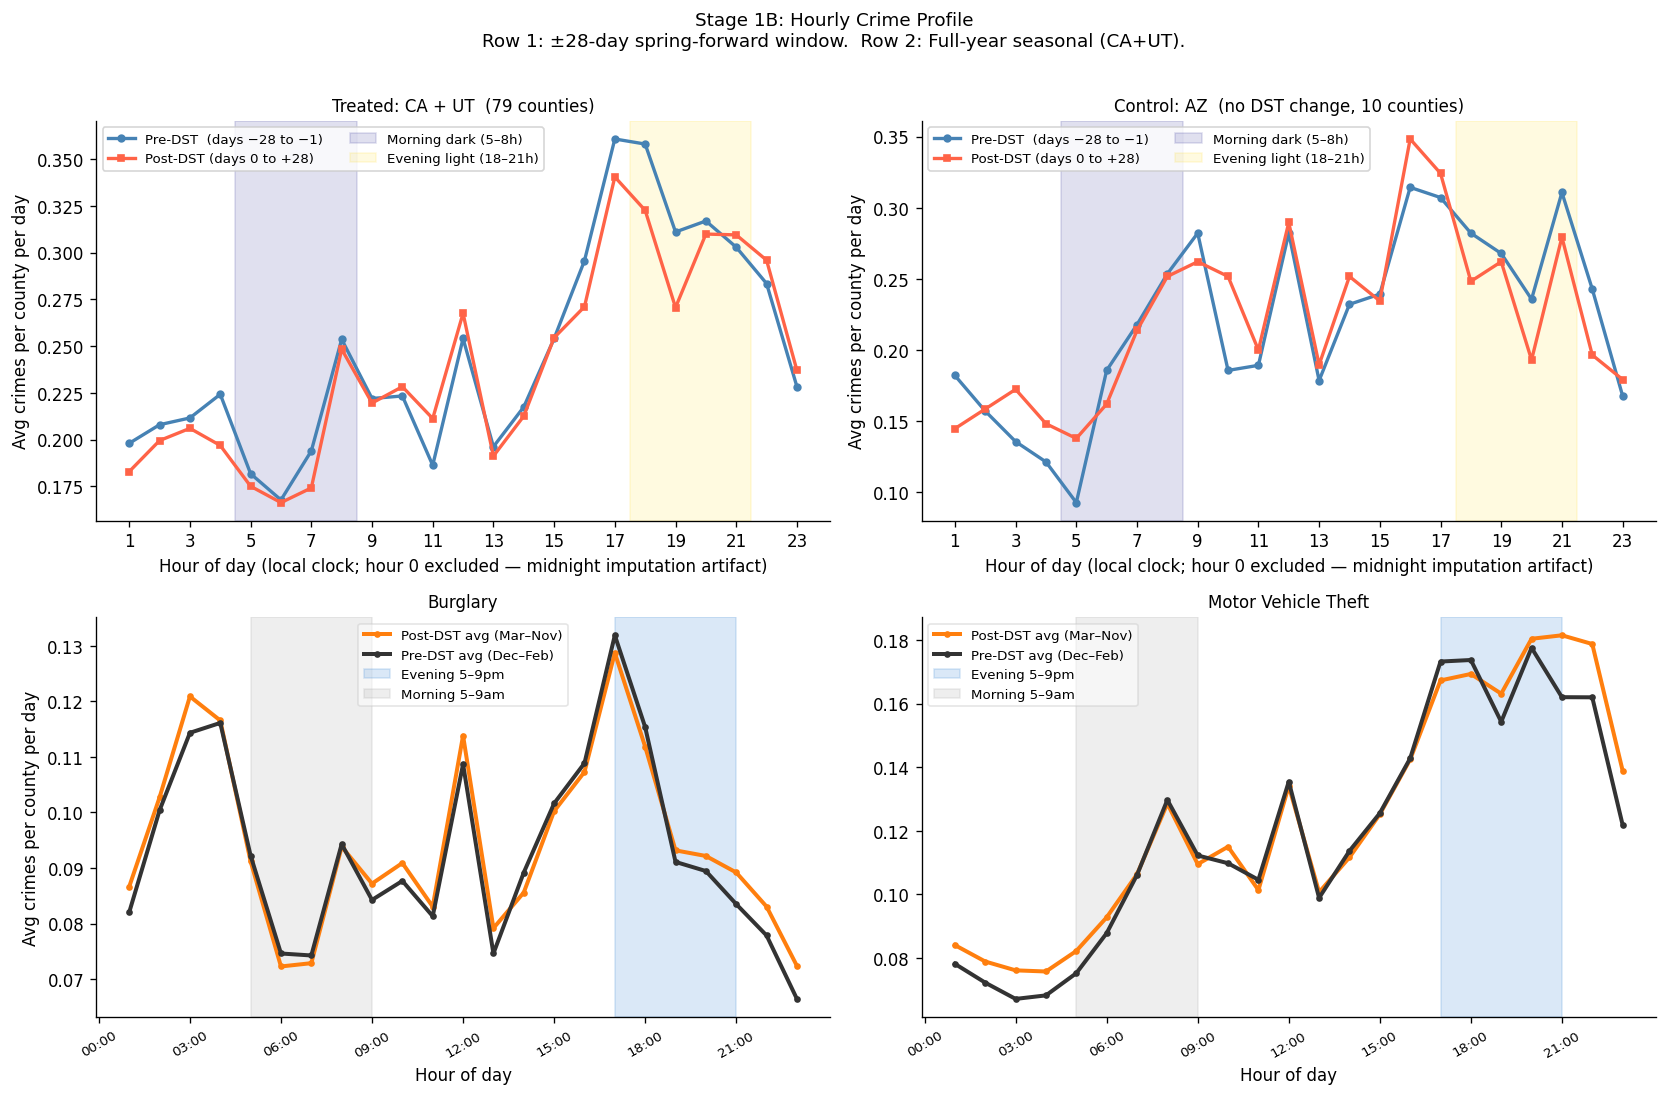

In [7]:
# Hourly profile — two rows:
# Row 1: ±28-day window, pre vs post (two clean lines), one panel per group
# Row 2: Full-year seasonal (pre-DST vs post-DST), by crime type
#
# Both rows use: sum(crime_count) / (n_counties × n_days)  [teammate's normalization]

hours_plot = list(range(1, 24))   # exclude hour 0

# ── Hourly avg helper (teammate's method) ────────────────────────────────
def hourly_avg(df, treated):
    sub   = df[df['treated_state'] == treated]
    n_c   = sub['county_fips'].nunique()
    n_pre  = sub[sub['post_dst'] == 0]['date'].nunique()
    n_post = sub[sub['post_dst'] == 1]['date'].nunique()
    agg = sub.groupby(['hour', 'post_dst'])['crime_count'].sum().unstack(fill_value=0)
    agg['pre']  = agg[0] / max(n_c * n_pre,  1)
    agg['post'] = agg[1] / max(n_c * n_post, 1)
    return agg.reindex(range(24))

prof_tr = hourly_avg(win, 1)   # CA + UT
prof_az = hourly_avg(win, 0)   # AZ

n_treated_counties = win[win['treated_state'] == 1]['county_fips'].nunique()
n_control_counties = win[win['treated_state'] == 0]['county_fips'].nunique()

# ── Seasonal hourly avg (same normalization) ──────────────────────────────
h_full = df_h[(df_h['treated_state'] == 1) & (df_h['hour'] != 0)].copy()
h_full['period'] = h_full['month'].apply(lambda m: 'DST' if 3 <= m <= 11 else 'standard')

seas_rows = []
for period in ['DST', 'standard']:
    sub_p = h_full[h_full['period'] == period]
    n_c = sub_p['county_fips'].nunique()
    n_d = sub_p[['year', 'month', 'day']].drop_duplicates().shape[0]
    for offense in CRIMES:
        sub = sub_p[sub_p['offense_type'] == offense]
        agg = sub.groupby('hour')['crime_count'].sum() / max(n_c * n_d, 1)
        for hour, val in agg.items():
            seas_rows.append({'period': period, 'offense_type': offense,
                              'hour': hour, 'avg': val})
seas_avg = pd.DataFrame(seas_rows)

PERIOD_COLORS_Q2 = {'DST': '#ff7f0e', 'standard': '#333333'}
PERIOD_LABELS_Q2 = {'DST': 'Post-DST avg (Mar–Nov)', 'standard': 'Pre-DST avg (Dec–Feb)'}

# ── Build figure ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Stage 1B: Hourly Crime Profile\n'
    'Row 1: ±28-day spring-forward window.  Row 2: Full-year seasonal (CA+UT).',
    fontsize=11, y=1.01,
)

# ── ROW 1 ─────────────────────────────────────────────────────────────────
panel_specs = [
    (prof_tr, f'Treated: CA + UT  ({n_treated_counties} counties)'),
    (prof_az, f'Control: AZ  (no DST change, {n_control_counties} counties)'),
]
for col, (prof, panel_title) in enumerate(panel_specs):
    ax = axes[0][col]
    ax.plot(hours_plot, prof.loc[hours_plot, 'pre'].values,
            color='steelblue', lw=2, marker='o', ms=4, label='Pre-DST  (days −28 to −1)')
    ax.plot(hours_plot, prof.loc[hours_plot, 'post'].values,
            color='tomato',    lw=2, marker='s', ms=4, label='Post-DST (days 0 to +28)')
    ax.axvspan(4.5,  8.5,  alpha=0.12, color='navy', label='Morning dark (5–8h)')
    ax.axvspan(17.5, 21.5, alpha=0.12, color='gold', label='Evening light (18–21h)')
    ax.set_title(panel_title, fontsize=10)
    ax.set_xlabel('Hour of day (local clock; hour 0 excluded — midnight imputation artifact)')
    ax.set_ylabel('Avg crimes per county per day')
    ax.set_xticks(range(1, 24, 2))
    ax.legend(fontsize=8, ncol=2, loc='upper left')

# ── ROW 2 ─────────────────────────────────────────────────────────────────
for col, crime in enumerate(CRIMES):
    ax2 = axes[1][col]
    for period, color in PERIOD_COLORS_Q2.items():
        s = seas_avg[(seas_avg['offense_type'] == crime) &
                     (seas_avg['period'] == period)].sort_values('hour')
        ax2.plot(s['hour'], s['avg'], color=color, lw=2.4, marker='o', ms=3,
                 label=PERIOD_LABELS_Q2[period])
    ax2.axvspan(17, 21, alpha=0.2, color='#4a90d9', label='Evening 5–9pm')
    ax2.axvspan(5,  9,  alpha=0.2, color='#aaaaaa', label='Morning 5–9am')
    ax2.set_title(CRIME_LABELS[crime], fontsize=10)
    ax2.set_xlabel('Hour of day')
    ax2.set_xticks(range(0, 24, 3))
    ax2.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)], rotation=30, fontsize=8)
    if col == 0:
        ax2.set_ylabel('Avg crimes per county per day')
    ax2.legend(fontsize=8, framealpha=0.5)

plt.tight_layout()
plt.show()

## Section 1C — Time-of-Day Bucket Summary

Collapses the 24-hour profile into four light-regime buckets (same ±28-day window, CA vs AZ, pre vs. post DST). The displacement hypothesis predicts CA's morning bucket rises and evening bucket falls after spring-forward, with no corresponding change in AZ.

In [8]:
# Stage 1C — Time-of-Day Bucket Analysis
# Buckets normalized to per-hour so unequal-size buckets are comparable.
# late_night hours: 1-4 + 22-23 = 6h (hour 0 excluded); morning_dark/evening_light = 4h; daytime = 9h

BUCKET_ORDER  = ['morning_dark', 'daytime', 'evening_light', 'late_night']
BUCKET_LABELS = {
    'morning_dark':  'Morning dark\n(5–8h)',
    'daytime':       'Daytime\n(9–17h)',
    'evening_light': 'Evening light\n(18–21h)',
    'late_night':    'Late night\n(1–4h, 22–23h)',
}
BUCKET_HOURS = {'morning_dark': 4, 'daytime': 9, 'evening_light': 4, 'late_night': 6}

# ── Data prep: daily bucket total per county, then mean/SE across county-days ──
win_nz = win[win['hour'] != 0].copy()
daily_bkt = (
    win_nz.groupby(['state', 'county_fips', 'post_dst', 'time_bucket', 'date'],
                   as_index=False)['crime_count'].sum()
)
bucket_agg = (
    daily_bkt.groupby(['state', 'post_dst', 'time_bucket'], as_index=False)
    .agg(mean_count=('crime_count', 'mean'),
         se_count=('crime_count', lambda x: x.std() / np.sqrt(len(x))))
)
# Normalize to per-hour
bucket_agg['mean_ph'] = bucket_agg.apply(
    lambda r: r['mean_count'] / BUCKET_HOURS[r['time_bucket']], axis=1)
bucket_agg['se_ph'] = bucket_agg.apply(
    lambda r: r['se_count']   / BUCKET_HOURS[r['time_bucket']], axis=1)



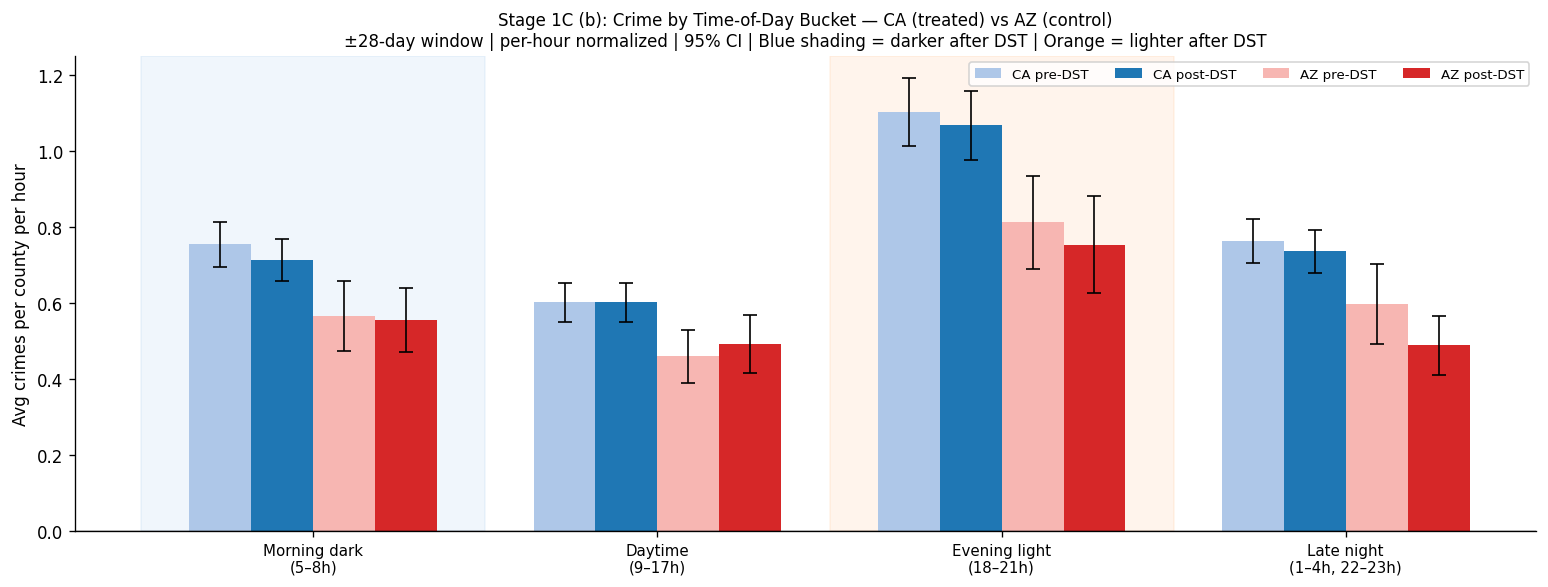

In [9]:
# Stage 1C (b): CA + AZ comparison, same per-hour normalization

PERIOD_LABELS_1C = {0: 'Pre-DST', 1: 'Post-DST'}
BOX_COLORS_1C = {
    ('CA', 0): '#aec7e8', ('CA', 1): '#1f77b4',
    ('AZ', 0): '#f7b6b2', ('AZ', 1): '#d62728',
}
BOX_LABELS_1C = {
    ('CA', 0): 'CA pre-DST', ('CA', 1): 'CA post-DST',
    ('AZ', 0): 'AZ pre-DST', ('AZ', 1): 'AZ post-DST',
}

x = np.arange(len(BUCKET_ORDER))
w = 0.18
offsets = {'CA_0': -1.5*w, 'CA_1': -0.5*w, 'AZ_0': 0.5*w, 'AZ_1': 1.5*w}

fig, ax = plt.subplots(figsize=(13, 5))
for state in ['CA', 'AZ']:
    for period in [0, 1]:
        sub = (bucket_agg[(bucket_agg['state'] == state) & (bucket_agg['post_dst'] == period)]
               .set_index('time_bucket').reindex(BUCKET_ORDER))
        offset = offsets[f'{state}_{period}']
        ax.bar(x + offset, sub['mean_ph'], w,
               color=BOX_COLORS_1C[(state, period)], label=BOX_LABELS_1C[(state, period)])
        ax.errorbar(x + offset, sub['mean_ph'], yerr=1.96*sub['se_ph'],
                    fmt='none', color='black', capsize=4, lw=1)

ax.axvspan(-0.5, 0.5, alpha=0.08, color='#4a90d9', zorder=0)
ax.axvspan( 1.5, 2.5, alpha=0.08, color='#ff7f0e', zorder=0)
ax.set_xticks(x)
ax.set_xticklabels([BUCKET_LABELS[b] for b in BUCKET_ORDER], fontsize=9)
ax.set_ylabel('Avg crimes per county per hour')
ax.set_title(
    'Stage 1C (b): Crime by Time-of-Day Bucket — CA (treated) vs AZ (control)\n'
    '±28-day window | per-hour normalized | 95% CI | '
    'Blue shading = darker after DST | Orange = lighter after DST',
    fontsize=10)
ax.legend(fontsize=8, ncol=4)
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

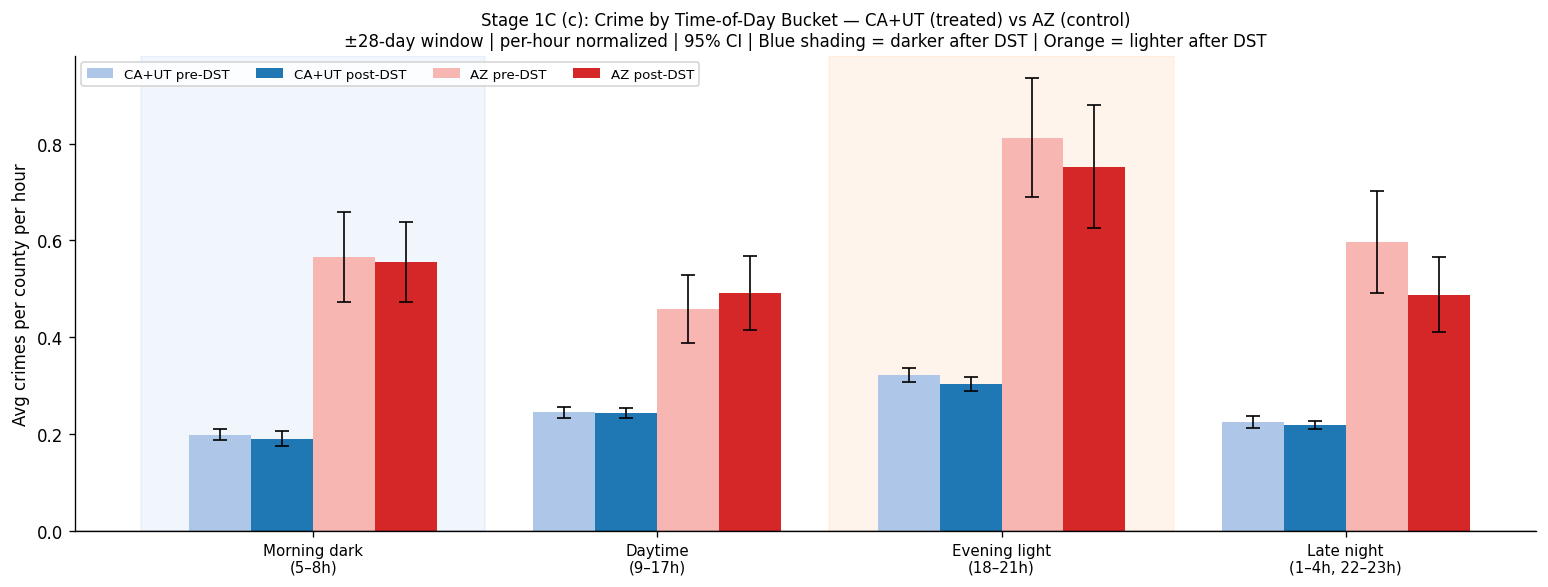

In [10]:
# Stage 1C (c): CA+UT (treated, blue) vs AZ (control, red)
# CA and UT are pooled as one treated group before normalization.

# Pool CA+UT daily bucket totals
daily_bkt_treated = daily_bkt[daily_bkt['state'].isin(['CA', 'UT'])].copy()

bucket_treated = (
    daily_bkt_treated
    .groupby(['post_dst', 'time_bucket', 'date'], as_index=False)['crime_count'].sum()
)
n_treated_c = daily_bkt_treated['county_fips'].nunique()
bucket_treated_agg = (
    bucket_treated.groupby(['post_dst', 'time_bucket'], as_index=False)
    .agg(mean_count=('crime_count', lambda x: x.sum() / max(n_treated_c * len(x), 1)),
         se_count=('crime_count',
                   lambda x: (x / n_treated_c).std() / np.sqrt(len(x))))
)
bucket_treated_agg['state'] = 'CA+UT'
bucket_treated_agg['mean_ph'] = bucket_treated_agg.apply(
    lambda r: r['mean_count'] / BUCKET_HOURS[r['time_bucket']], axis=1)
bucket_treated_agg['se_ph'] = bucket_treated_agg.apply(
    lambda r: r['se_count']   / BUCKET_HOURS[r['time_bucket']], axis=1)

az_agg = bucket_agg[bucket_agg['state'] == 'AZ'].copy()

BOX_COLORS_C = {
    ('CA+UT', 0): '#aec7e8', ('CA+UT', 1): '#1f77b4',
    ('AZ',    0): '#f7b6b2', ('AZ',    1): '#d62728',
}
BOX_LABELS_C = {
    ('CA+UT', 0): 'CA+UT pre-DST', ('CA+UT', 1): 'CA+UT post-DST',
    ('AZ',    0): 'AZ pre-DST',    ('AZ',    1): 'AZ post-DST',
}

x = np.arange(len(BUCKET_ORDER))
w = 0.18
offsets_c = {'CA+UT_0': -1.5*w, 'CA+UT_1': -0.5*w, 'AZ_0': 0.5*w, 'AZ_1': 1.5*w}

fig, ax = plt.subplots(figsize=(13, 5))
for state, src in [('CA+UT', bucket_treated_agg), ('AZ', az_agg)]:
    for period in [0, 1]:
        sub = (src[src['post_dst'] == period]
               .set_index('time_bucket').reindex(BUCKET_ORDER))
        offset = offsets_c[f'{state}_{period}']
        ax.bar(x + offset, sub['mean_ph'], w,
               color=BOX_COLORS_C[(state, period)], label=BOX_LABELS_C[(state, period)])
        ax.errorbar(x + offset, sub['mean_ph'], yerr=1.96*sub['se_ph'],
                    fmt='none', color='black', capsize=4, lw=1)

ax.axvspan(-0.5, 0.5, alpha=0.08, color='#4a90d9', zorder=0)
ax.axvspan( 1.5, 2.5, alpha=0.08, color='#ff7f0e', zorder=0)
ax.set_xticks(x)
ax.set_xticklabels([BUCKET_LABELS[b] for b in BUCKET_ORDER], fontsize=9)
ax.set_ylabel('Avg crimes per county per hour')
ax.set_title(
    'Stage 1C (c): Crime by Time-of-Day Bucket — CA+UT (treated) vs AZ (control)\n'
    '±28-day window | per-hour normalized | 95% CI | '
    'Blue shading = darker after DST | Orange = lighter after DST',
    fontsize=10)
ax.legend(fontsize=8, ncol=4)
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

## Section 1D — Displacement Regression (Within-State + Triple-Difference)

**Within-state model** (run separately for treated CA+UT and control AZ):
```
crime_count ~ post_dst × C(time_bucket, ref='late_night')
            + C(county_fips) + C(day_of_week) + C(offense_type)
```
Reference group: `late_night` bucket in pre-DST period. Positive `morning_dark` + negative `evening_light` would support the displacement hypothesis.

**Triple-difference model** adds `treated_state` (1 = CA or UT, 0 = AZ) to test whether any within-day shift in treated states is *differential* relative to AZ:
```
crime_count ~ treated_state × post_dst × C(time_bucket, ref='late_night')
            + C(county_fips) + C(day_of_week) + C(offense_type)
```
The triple interaction is the key DST mechanism test.

**Three-panel plot:** Panel 1 = CA+UT within-state shift, Panel 2 = AZ placebo (should be flat), Panel 3 = triple-diff (CA+UT − AZ differential shift).

In [11]:
# ── Within-state displacement regression ─────────────────────────────────
def run_within_reg(df, label):
    d = df[df['time_bucket'] != 'daytime'].copy()
    d['time_bucket'] = pd.Categorical(
        d['time_bucket'],
        categories=['late_night', 'morning_dark', 'evening_light']
    )

    formula = (
        'crime_count '
        '~ post_dst * C(time_bucket, Treatment("late_night")) '
        '+ C(county_fips) + C(day_of_week) + C(offense_type)'
    )

    return smf.ols(formula, data=d).fit(cov_type='HC3')


# ── Run models ───────────────────────────────────────────────────────────
res_ca = run_within_reg(win[win['state'] == 'CA'], 'CA only')
res_tr = run_within_reg(win[win['state'].isin(['CA', 'UT'])], 'CA + UT')
res_az = run_within_reg(win[win['state'] == 'AZ'], 'AZ')


# ── Triple-difference model: CA + UT vs AZ ───────────────────────────────
d3 = win[win['state'].isin(['CA', 'UT', 'AZ'])].copy()
d3 = d3[d3['time_bucket'] != 'daytime'].copy()

d3['treated_state'] = d3['state'].isin(['CA', 'UT']).astype(int)
d3['time_bucket'] = pd.Categorical(
    d3['time_bucket'],
    categories=['late_night', 'morning_dark', 'evening_light']
)

res3 = smf.ols(
    'crime_count '
    '~ treated_state * post_dst * C(time_bucket, Treatment("late_night")) '
    '+ C(county_fips) + C(day_of_week) + C(offense_type)',
    data=d3
).fit(cov_type='HC3')


# ── Print summary tables ─────────────────────────────────────────────────
def fmt_interactions_within(res, label):
    rows = []
    for name in res.params.index:
        if 'post_dst' in name and 'time_bucket' in name:
            bucket = 'morning_dark' if 'morning' in name else 'evening_light'
            p = res.pvalues[name]
            rows.append({
                'Group': label,
                'Bucket': bucket,
                'Coef': round(res.params[name], 4),
                'SE': round(res.bse[name], 4),
                'p': round(p, 4),
                'Sig': '**' if p < 0.05 else ('*' if p < 0.10 else '')
            })
    return rows


within_tbl = pd.DataFrame(
    fmt_interactions_within(res_ca, 'CA only') +
    fmt_interactions_within(res_tr, 'CA + UT') +
    fmt_interactions_within(res_az, 'AZ')
)

print('Within-state displacement regression')
print('Reference bucket: late_night; reference period: pre-DST')
print(within_tbl.to_string(index=False))


did_rows = []
for name in res3.params.index:
    if all(k in name for k in ['treated_state', 'post_dst', 'time_bucket']):
        bucket = 'morning_dark' if 'morning' in name else 'evening_light'
        p = res3.pvalues[name]
        did_rows.append({
            'Bucket': bucket,
            'Coef': round(res3.params[name], 4),
            'SE': round(res3.bse[name], 4),
            'p': round(p, 4),
            'Sig': '**' if p < 0.05 else ('*' if p < 0.10 else '')
        })

print('\nTriple-difference: CA+UT vs AZ differential shift')
print(pd.DataFrame(did_rows).to_string(index=False))

Within-state displacement regression
Reference bucket: late_night; reference period: pre-DST
  Group        Bucket    Coef     SE      p Sig
CA only  morning_dark -0.0190 0.0336 0.5720    
CA only evening_light -0.0565 0.0358 0.1148    
CA + UT  morning_dark -0.0188 0.0321 0.5573    
CA + UT evening_light -0.0515 0.0342 0.1314    
     AZ  morning_dark  0.0206 0.0636 0.7466    
     AZ evening_light  0.0016 0.0678 0.9815    

Triple-difference: CA+UT vs AZ differential shift
       Bucket    Coef     SE      p Sig
 morning_dark -0.0440 0.0637 0.4895    
evening_light -0.0554 0.0674 0.4110    


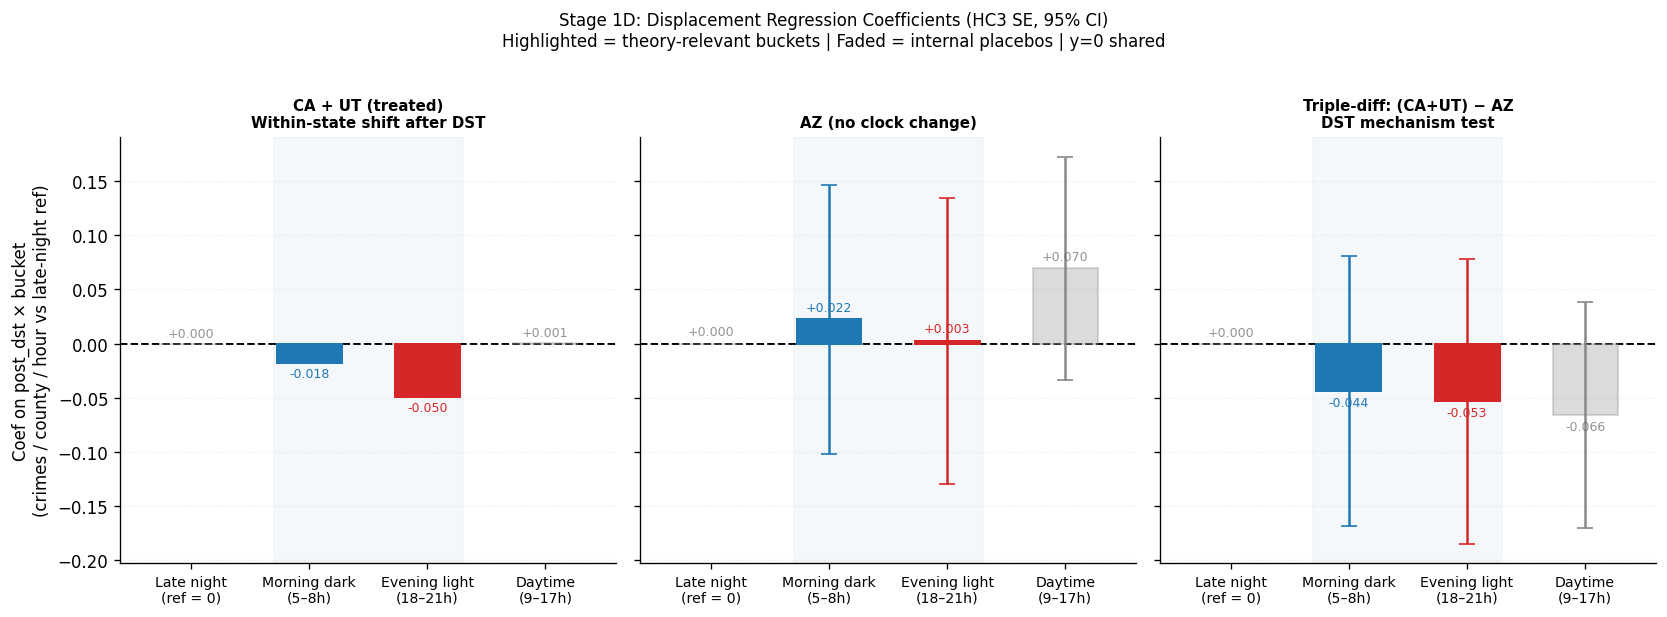

In [12]:
# Three-panel coefficient plot
# Bar chart: volume = effect size. Coefficient label on every bar for readability.
# morning_dark + evening_light highlighted; daytime + late_night faded.

def run_within_full(df):
    d = df.copy()
    d['time_bucket'] = pd.Categorical(
        d['time_bucket'],
        categories=['late_night', 'morning_dark', 'daytime', 'evening_light']
    )
    formula = (
        'crime_count '
        '~ post_dst * C(time_bucket, Treatment("late_night")) '
        '+ C(county_fips) + C(day_of_week) + C(offense_type)'
    )
    return smf.ols(formula, data=d).fit(cov_type='HC3')

d3_full = win.copy()
d3_full['time_bucket'] = pd.Categorical(
    d3_full['time_bucket'],
    categories=['late_night', 'morning_dark', 'daytime', 'evening_light']
)

res_tr_v = run_within_full(win[win['treated_state'] == 1])
res_az_v = run_within_full(win[win['treated_state'] == 0])
res3_v   = smf.ols(
    'crime_count '
    '~ treated_state * post_dst * C(time_bucket, Treatment("late_night")) '
    '+ C(county_fips) + C(day_of_week) + C(offense_type)',
    data=d3_full
).fit(cov_type='HC3')

def get_bar(res, bucket, triple=False):
    if bucket == 'late_night':
        return 0.0, 0.0
    if triple:
        keys = [k for k in res.params.index
                if all(x in k for x in ['treated_state', 'post_dst', bucket])]
    else:
        keys = [k for k in res.params.index
                if 'post_dst' in k and bucket in k and 'treated_state' not in k]
    if not keys:
        return 0.0, 0.0
    k = keys[0]
    return res.params[k], 1.96 * res.bse[k]

DISPLAY_ORDER = ['late_night', 'morning_dark', 'evening_light', 'daytime']
BUCKET_XLABELS_V = {
    'late_night':    'Late night\n(ref = 0)',
    'morning_dark':  'Morning dark\n(5–8h)',
    'evening_light': 'Evening light\n(18–21h)',
    'daytime':       'Daytime\n(9–17h)',
}
BUCKET_COLOR = {
    'morning_dark':  '#1f77b4',
    'evening_light': '#d62728',
    'daytime':       '#888888',
    'late_night':    '#888888',
}
BUCKET_ALPHA = {
    'morning_dark': 1.0, 'evening_light': 1.0,
    'daytime': 0.30,     'late_night': 0.30,
}

panel_specs_v = [
    ('CA + UT (treated)\nWithin-state shift after DST',  res_tr_v, False),
    ('AZ (no clock change)',   res_az_v, False),
    ('Triple-diff: (CA+UT) − AZ\nDST mechanism test',   res3_v,   True),
]

x_pos = np.arange(len(DISPLAY_ORDER))
bar_w = 0.55

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle(
    'Stage 1D: Displacement Regression Coefficients (HC3 SE, 95% CI)\n'
    'Highlighted = theory-relevant buckets | Faded = internal placebos | y=0 shared',
    fontsize=10, y=1.02,
)

for ax, (title, res, triple) in zip(axes, panel_specs_v):
    coefs = [get_bar(res, bk, triple) for bk in DISPLAY_ORDER]
    y_vals = [c for c, _ in coefs]
    y_max  = max(abs(v) for v in y_vals if v != 0) or 1

    for i, bk in enumerate(DISPLAY_ORDER):
        coef, ci = coefs[i]
        color = BUCKET_COLOR[bk]
        alpha = BUCKET_ALPHA[bk]

        # Bar with matching edge so even tiny bars show an outline
        ax.bar(i, coef, bar_w,
               color=color, alpha=alpha,
               edgecolor=color, linewidth=1.2, zorder=2)

        # CI error bar (skip reference)
        if bk != 'late_night':
            ax.errorbar(i, coef, yerr=ci,
                        fmt='none', color=color, capsize=5, lw=1.5, zorder=3)

        # Coefficient label just outside the bar tip
        offset = y_max * 0.07
        va = 'bottom' if coef >= 0 else 'top'
        y_label = coef + offset if coef >= 0 else coef - offset
        ax.text(i, y_label, f'{coef:+.3f}',
                ha='center', va=va, fontsize=7.5,
                color=color if alpha == 1.0 else '#666666',
                alpha=max(alpha, 0.7), zorder=4)

    ax.axhline(0, color='black', lw=1.2, ls='--', zorder=1)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([BUCKET_XLABELS_V[b] for b in DISPLAY_ORDER], fontsize=8.5)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.25, linestyle=':')
    ax.set_xlim(-0.6, len(DISPLAY_ORDER) - 0.4)

axes[0].set_ylabel('Coef on post_dst × bucket\n(crimes / county / hour vs late-night ref)')

for ax in axes:
    ax.axvspan(0.7, 2.3, alpha=0.05, color='steelblue', zorder=0)

plt.tight_layout()
plt.show()

In [13]:
for bk in DISPLAY_ORDER:
    coef, ci = get_bar(res_tr_v, bk, triple=False)
    print(bk, "coef =", coef, "95% CI half-width =", ci)

late_night coef = 0.0 95% CI half-width = 0.0
morning_dark coef = -0.0183162626990235 95% CI half-width = inf
evening_light coef = -0.04963890727556851 95% CI half-width = inf
daytime coef = 0.000517509922414644 95% CI half-width = inf


---
# Stage 2 — Cross-State Difference-in-Differences (CA vs AZ)

**Source:** Pre-built model panel `focus_states_daily_county_model_panel_2022_2024.csv`.  
**Treated:** California counties where `observes_dst_county == True`.  
**Control:** Arizona counties where `is_az_control == True` and `observes_dst_county == False` (Navajo Nation excluded).  
**Robustness check:** Utah is included as an additional treated state in alternative specifications to verify that results are not driven solely by California.


## Section 2.1 — Load Panel and Build Estimation Sample

In [14]:
# ── Load pre-built panel ──────────────────────────────────────────────────
raw = pd.read_csv(PANEL_PATH, low_memory=False, parse_dates=['incident_date'])

print(f'Full panel shape: {raw.shape}')
print(f'States in panel: {sorted(raw["state"].unique())}')

# ── Build CA-only estimation sample ──────────────────────────────────────
# Treated: CA counties that observe DST (excludes any county-level exceptions)
# Control: AZ counties on America/Phoenix time (Navajo Nation excluded)
treated_mask = (raw['state'] == 'CA') & raw['observes_dst_county']
control_mask = raw['is_az_control'] & ~raw['observes_dst_county']
sample = raw[treated_mask | control_mask].copy()

# ── Add derived variables ─────────────────────────────────────────────────
sample['year_month'] = sample['incident_date'].dt.to_period('M').astype(str)
sample['data_year']  = sample['incident_date'].dt.year.astype(int)
sample['log_rate']   = np.log1p(sample['crime_rate_per_100k'])
sample['group']      = sample['state'].map({'CA': 'California (treated)', 'AZ': 'Arizona (control)'})

# Filter to target crime types
sample = sample[sample['crime_type'].isin(CRIMES)].copy()

county_counts = sample.drop_duplicates(['state', 'county_fips']).groupby('state').size()
print(f'\nEstimation sample: {len(sample):,} rows')
print('Counties per state:')
print(county_counts.rename('n_counties').to_frame())
print(f'\nDST window coverage (should be ~0.65 for CA, 0.00 for AZ):')
print(sample.groupby(['state', 'data_year'])['in_dst_window'].mean().round(3))

Full panel shape: (782544, 30)
States in panel: ['AZ', 'CA', 'NV', 'UT']

Estimation sample: 153,440 rows
Counties per state:
       n_counties
state            
AZ             12
CA             58

DST window coverage (should be ~0.65 for CA, 0.00 for AZ):
state  data_year
AZ     2022         0.000
       2023         0.000
       2024         0.000
CA     2022         0.655
       2023         0.655
       2024         0.653
Name: in_dst_window, dtype: float64


## Section 2.2 — Monthly Crime Rate Trends (CA vs AZ)

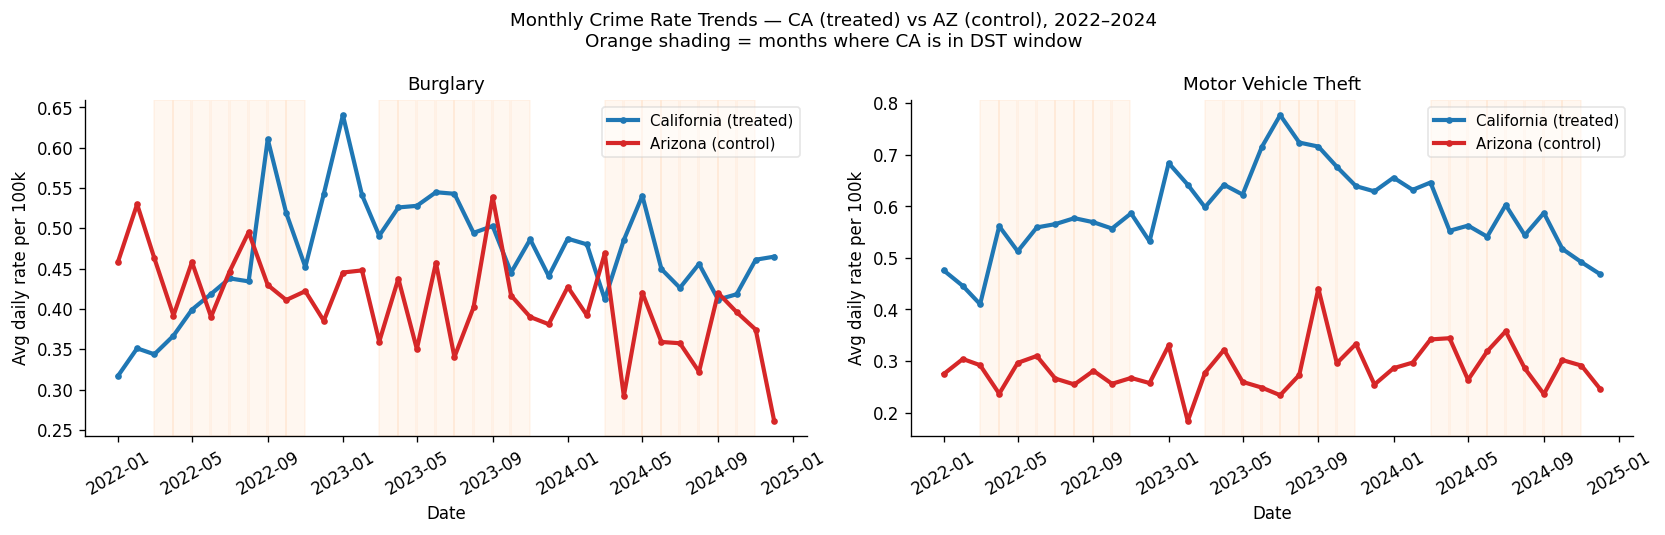

In [15]:
# Monthly average rates by group and crime type
monthly = (
    sample.groupby(['group', 'year_month', 'crime_type'], as_index=False)
    .agg(mean_rate=('crime_rate_per_100k', 'mean'), in_dst=('in_dst_window', 'mean'))
)
monthly['date'] = pd.to_datetime(monthly['year_month'])

GROUP_COLORS = {'California (treated)': STATE_COLORS['CA'], 'Arizona (control)': STATE_COLORS['AZ']}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(
    'Monthly Crime Rate Trends — CA (treated) vs AZ (control), 2022–2024\n'
    'Orange shading = months where CA is in DST window',
    fontsize=11,
)

for ax, ct in zip(axes, CRIMES):
    sub = monthly[monthly['crime_type'] == ct].sort_values('date')

    # Shade DST window months for CA
    dst_months = sub[sub['in_dst'] > 0.5]['date'].values
    prev_date  = None
    for d in dst_months:
        ax.axvspan(d, d + pd.offsets.MonthEnd(0), alpha=0.06, color='#ff7f0e', zorder=0)

    for group, color in GROUP_COLORS.items():
        s = sub[sub['group'] == group]
        ax.plot(s['date'], s['mean_rate'], color=color, lw=2.5, marker='o', ms=3,
                label=group)

    ax.set_title(CRIME_LABELS[ct], fontsize=11)
    ax.set_xlabel('Date')
    ax.set_ylabel('Avg daily rate per 100k')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.show()

## Section 2.3 — Pre-Trends Visual (Weeks Around Spring-Forward)

Plots weekly average crime rates relative to the spring-forward date for CA and AZ. Flat and parallel lines in the pre-period (weeks −8 to −1) support the parallel trends assumption needed for DiD.

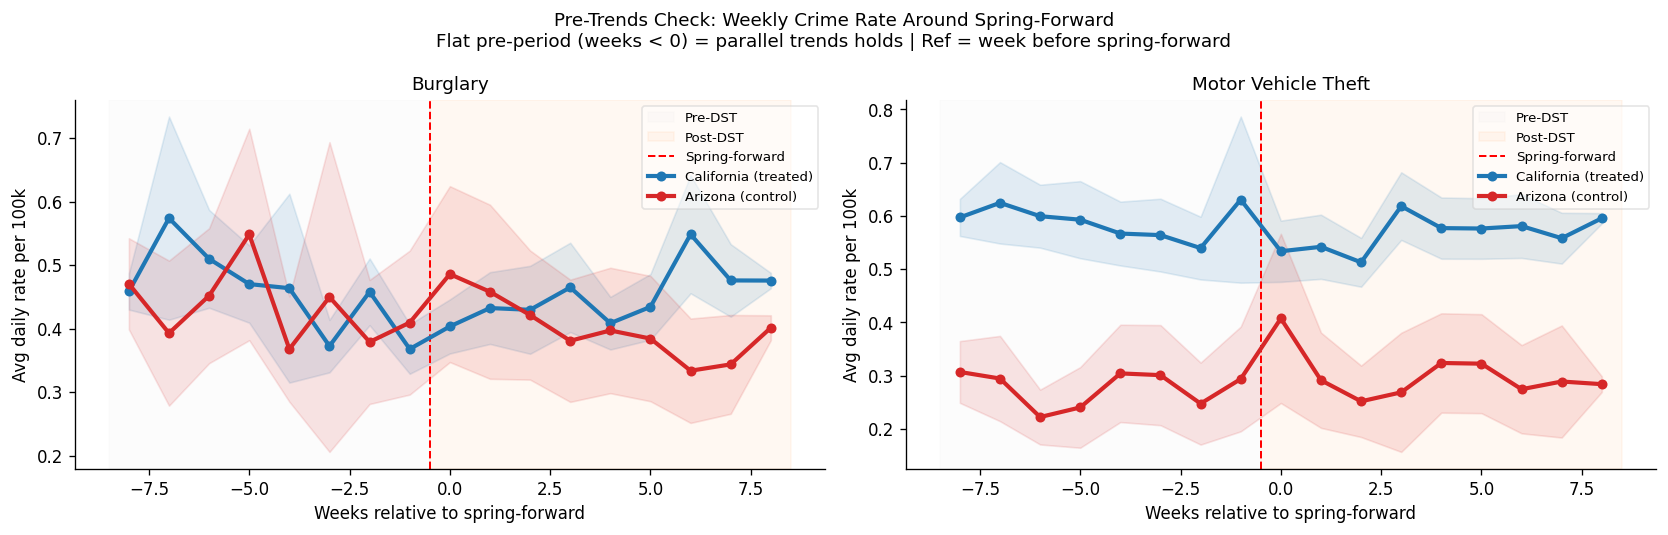

In [16]:
pre_post = sample.copy()
pre_post['week_from_start'] = (pre_post['days_from_dst_start'] // 7).clip(-8, 8)

pre_post_agg = (
    pre_post.groupby(['group', 'week_from_start', 'crime_type'], as_index=False)
    .agg(
        mean_rate=('crime_rate_per_100k', 'mean'),
        se_rate=('crime_rate_per_100k', lambda x: x.std() / np.sqrt(len(x)))
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(
    'Pre-Trends Check: Weekly Crime Rate Around Spring-Forward\n'
    'Flat pre-period (weeks < 0) = parallel trends holds | Ref = week before spring-forward',
    fontsize=11,
)

for ax, ct in zip(axes, CRIMES):
    sub = pre_post_agg[pre_post_agg['crime_type'] == ct]

    ax.axvspan(-8.5, -0.5, alpha=0.05, color='lightgray', zorder=0, label='Pre-DST')
    ax.axvspan(-0.5,  8.5, alpha=0.05, color='#ff7f0e',   zorder=0, label='Post-DST')
    ax.axvline(-0.5, color='red', lw=1.2, ls='--', label='Spring-forward')

    for group, color in GROUP_COLORS.items():
        s = sub[sub['group'] == group].sort_values('week_from_start')
        ax.fill_between(s['week_from_start'],
                        s['mean_rate'] - 1.96*s['se_rate'],
                        s['mean_rate'] + 1.96*s['se_rate'],
                        color=color, alpha=0.12)
        ax.plot(s['week_from_start'], s['mean_rate'],
                color=color, lw=2.5, marker='o', ms=5, label=group, zorder=3)

    ax.set_title(CRIME_LABELS[ct], fontsize=11)
    ax.set_xlabel('Weeks relative to spring-forward')
    ax.set_ylabel('Avg daily rate per 100k')
    ax.legend(fontsize=8, framealpha=0.5)

plt.tight_layout()
plt.show()

## Section 2.4 — Main TWFE DiD

**Specification:**
$$\text{rate}_{ct} = \beta \cdot \text{InDSTWindow}_{ct} + \gamma \cdot \text{Controls}_{ct} + \alpha_c + \lambda_{ym} + \varepsilon_{ct}$$

County FEs ($\alpha_c$) and year-month FEs ($\lambda_{ym}$) absorbed via within-transformation (FWL theorem). Standard errors clustered at county level.

| Spec | Description |
|---|---|
| M1 Baseline | `in_dst_window + is_weekend + is_holiday + county FE + year-month FE` |
| M2 + Socio | M1 + median income, poverty rate, unemployment, education |
| M3 Log rate | M1 with `log(crime rate)` as outcome |

In [17]:
# ── TWFE helper (FWL within-transformation) ───────────────────────────────
def run_twfe(df, outcome, regressors,
             entity='county_fips', time='year_month', cluster='county_fips'):
    """
    TWFE OLS via sequential within-transformation (FWL theorem).
    Absorbs county FE then time FE. Clusters SEs at county level.
    """
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d = df[cols].dropna(subset=[outcome] + regressors).copy()
    for c in [outcome] + regressors:
        d[c] = d[c].astype(float)

    e_means = d.groupby(entity)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - e_means
    t_means = d.groupby(time)[[outcome] + regressors].transform('mean')
    d[[outcome] + regressors] = d[[outcome] + regressors] - t_means

    X      = sm.add_constant(d[regressors])
    groups = df.loc[d.index, cluster].values
    return sm.OLS(d[outcome], X).fit(cov_type='cluster', cov_kwds={'groups': groups})


def results_table(results_dict, treatment_var='in_dst_window'):
    rows = []
    for label, res in results_dict.items():
        coef = res.params.get(treatment_var, np.nan)
        se   = res.bse.get(treatment_var, np.nan)
        pval = res.pvalues.get(treatment_var, np.nan)
        sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        rows.append({
            'Specification': label,
            'Coef':    round(coef, 5),
            'SE':      f'({round(se, 5)})',
            'Sig':     sig,
            'p-value': round(pval, 4),
            '95% CI':  f'[{coef - 1.96*se:.4f}, {coef + 1.96*se:.4f}]',
            'N':       int(res.nobs),
        })
    return pd.DataFrame(rows)


print('TWFE functions defined.')

TWFE functions defined.


In [18]:
BASE_CONTROLS  = ['in_dst_window', 'is_weekend', 'is_holiday']
SOCIO_CONTROLS = BASE_CONTROLS + [
    'median_household_income', 'poverty_rate', 'unemployment_rate', 'bachelors_plus_rate'
]

results = {}
for ct in CRIMES:
    sub = sample[sample['crime_type'] == ct].copy()
    results[f'{CRIME_LABELS[ct]} | M1 Baseline'] = run_twfe(sub, 'crime_rate_per_100k', BASE_CONTROLS)
    results[f'{CRIME_LABELS[ct]} | M2 Log rate'] = run_twfe(sub, 'log_rate',            BASE_CONTROLS)

print('=== MAIN TWFE RESULTS ===')
print(results_table(results).to_string(index=False))
print('\nFE: county + year-month. SE clustered at county level.')
print('*** p<0.01  ** p<0.05  * p<0.1')

=== MAIN TWFE RESULTS ===
                    Specification     Coef        SE Sig  p-value            95% CI     N
           Burglary | M1 Baseline  0.01665 (0.01351)       0.2178 [-0.0098, 0.0431] 76720
           Burglary | M2 Log rate  0.00439 (0.00544)       0.4191 [-0.0063, 0.0151] 76720
Motor Vehicle Theft | M1 Baseline -0.00845 (0.01956)       0.6659 [-0.0468, 0.0299] 76720
Motor Vehicle Theft | M2 Log rate  0.00372 (0.00524)       0.4777 [-0.0066, 0.0140] 76720

FE: county + year-month. SE clustered at county level.
*** p<0.01  ** p<0.05  * p<0.1


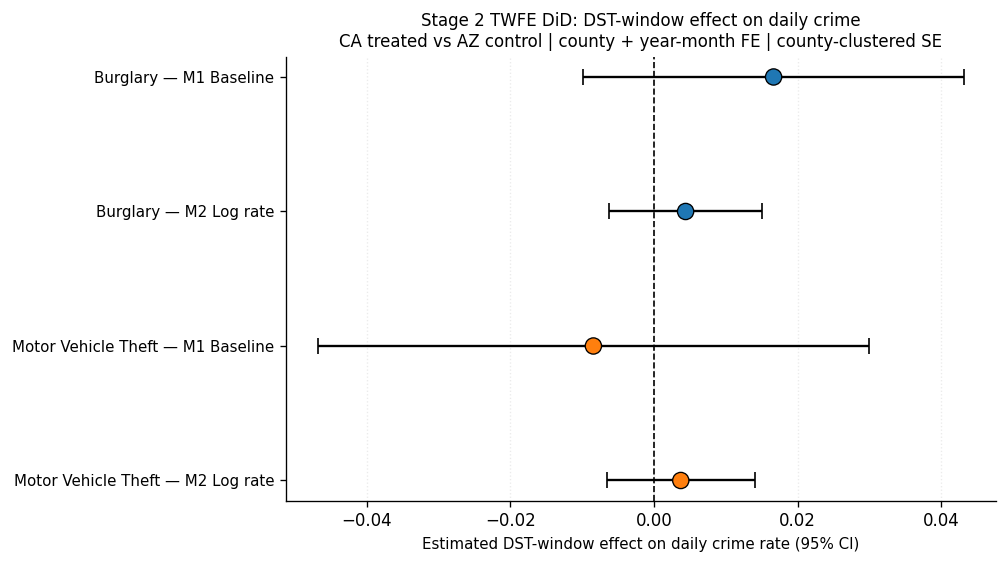

In [19]:
# ── Coefficient plot: baseline + log rate dot plot ───────────────────────
# Dot = point estimate; horizontal line = 95% CI

colors = {
    'Burglary': STATE_COLORS['CA'],
    'Motor Vehicle Theft': '#ff7f0e'
}

coefs, ses, labels, pt_colors = [], [], [], []

SPEC_SUFFIXES = ['M1 Baseline', 'M2 Log rate']

for ct in CRIMES:
    crime_label = CRIME_LABELS[ct]

    for spec in SPEC_SUFFIXES:
        key = f'{crime_label} | {spec}'

        if key not in results:
            continue

        r = results[key]

        coef = r.params.get('in_dst_window', np.nan)
        se = r.bse.get('in_dst_window', np.nan)

        if not np.isfinite(coef) or not np.isfinite(se):
            continue

        coefs.append(coef)
        ses.append(se)
        labels.append(f'{crime_label} — {spec}')
        pt_colors.append(colors.get(crime_label, '#333333'))

coefs = np.array(coefs)
ses = np.array(ses)
ci95 = 1.96 * ses
y_pos = np.arange(len(labels))[::-1]

fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.errorbar(
    coefs,
    y_pos,
    xerr=ci95,
    fmt='none',
    color='black',
    elinewidth=1.4,
    capsize=5,
    zorder=2
)

ax.scatter(
    coefs,
    y_pos,
    color=pt_colors,
    s=95,
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)

ax.axvline(0, color='black', lw=1.0, ls='--')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel('Estimated DST-window effect on daily crime rate (95% CI)', fontsize=9)
ax.set_title(
    'Stage 2 TWFE DiD: DST-window effect on daily crime\n'
    'CA treated vs AZ control | county + year-month FE | county-clustered SE',
    fontsize=10
)

ax.grid(axis='x', alpha=0.25, linestyle=':')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Section 2.5 — Event Study (Spring-Forward + Fall-Back)

**Dynamic DiD** estimating week-by-week treatment effects. Two things to check:
- **Pre-period (bins < 0):** Coefficients near zero validates parallel trends
- **Post-period (bins ≥ 0):** Any shift indicates a DST effect

Reference bin: week −1 (week immediately before spring-forward). Bins = floor(days / 7), clipped to [−8, +8].

In [20]:
# ── Event study function ──────────────────────────────────────────────────
def run_event_study(df, outcome, days_col='days_from_dst_start',
                    entity='county_fips', time='data_year',
                    cluster='county_fips', clip=(-8, 8), ref_bin=-1):
    d = df.copy()
    d['week_rel'] = (d[days_col] // 7).clip(*clip)
    d['treated']  = (d['state'] == 'CA').astype(float)
    bins = [b for b in sorted(d['week_rel'].dropna().unique()) if b != ref_bin]

    dum_cols = []
    for b in bins:
        col = f'tw_{b:+d}'
        d[col] = d['treated'] * (d['week_rel'] == b).astype(float)
        dum_cols.append(col)

    regressors = dum_cols + ['is_weekend', 'is_holiday']
    cols = list(dict.fromkeys([outcome] + regressors + [entity, time, cluster]))
    d2 = d[cols].dropna(subset=[outcome]).copy()
    for c in [outcome] + regressors:
        d2[c] = d2[c].astype(float)

    em = d2.groupby(entity)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - em
    tm = d2.groupby(time)[[outcome] + regressors].transform('mean')
    d2[[outcome] + regressors] = d2[[outcome] + regressors] - tm

    X      = sm.add_constant(d2[regressors])
    groups = d.loc[d2.index, cluster].values
    res    = sm.OLS(d2[outcome], X).fit(cov_type='cluster', cov_kwds={'groups': groups})

    rows = []
    for b, col in zip(bins, dum_cols):
        if col in res.params.index:
            ci = res.conf_int().loc[col]
            rows.append({'week': b, 'coef': res.params[col],
                         'ci_lo': ci[0], 'ci_hi': ci[1], 'pval': res.pvalues[col]})
    rows.append({'week': ref_bin, 'coef': 0.0, 'ci_lo': 0.0, 'ci_hi': 0.0, 'pval': 1.0})
    return pd.DataFrame(rows).sort_values('week').reset_index(drop=True)


def plot_event_study(es_df, title, ax, color=None):
    if color is None: color = '#1f77b4'
    ax.fill_between(es_df['week'], es_df['ci_lo'], es_df['ci_hi'], alpha=0.15, color=color)
    ax.plot(es_df['week'], es_df['coef'], 'o-', color=color, lw=2, ms=5)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(-0.5, color='red', ls='--', lw=1, label='Transition')
    ax.axvspan(-8, -0.5, alpha=0.05, color='lightgray', label='Pre-period')
    ax.set_xlabel('Weeks relative to transition')
    ax.set_ylabel('DiD coef (rate per 100k)')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)


print('Event study functions defined.')

Event study functions defined.


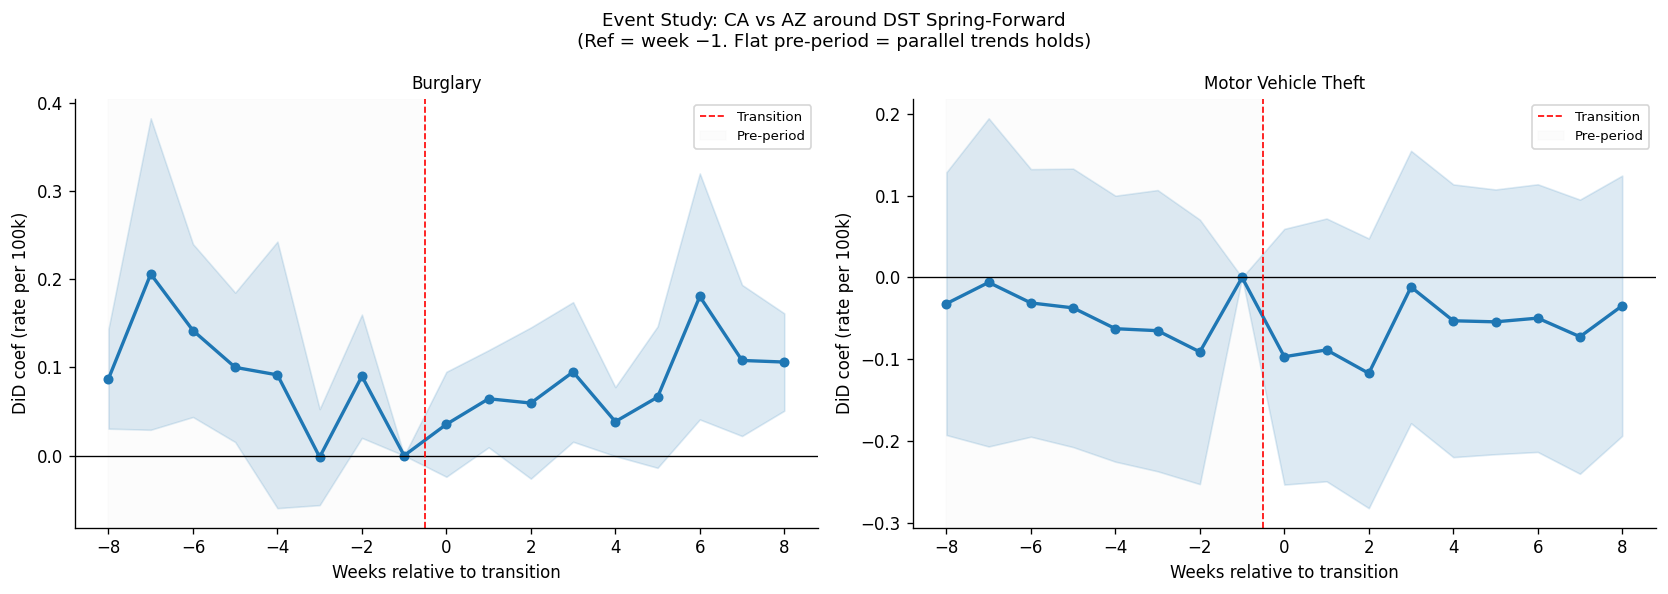

Pre-trend test (weeks −8 to −2):
Crime type                Significant bins (p<0.1)  Result
-----------------------------------------------------------------
Burglary                  5/7 bins at p<0.1        ⚠ May be violated
Motor Vehicle Theft       0/7 bins at p<0.1        ✓ Passes


In [21]:
# ── Spring-forward event study ────────────────────────────────────────────
es_sf = {ct: run_event_study(sample[sample['crime_type'] == ct], 'crime_rate_per_100k',
                              days_col='days_from_dst_start') for ct in CRIMES}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Event Study: CA vs AZ around DST Spring-Forward\n'
    '(Ref = week −1. Flat pre-period = parallel trends holds)',
    fontsize=11
)
for ax, ct in zip(axes, CRIMES):
    plot_event_study(es_sf[ct], CRIME_LABELS[ct], ax, color=STATE_COLORS['CA'])
plt.tight_layout()
plt.show()

print('Pre-trend test (weeks −8 to −2):')
print(f'{"Crime type":<25} {"Significant bins (p<0.1)":<25} Result')
print('-' * 65)
for ct in CRIMES:
    pre  = es_sf[ct][es_sf[ct]['week'] <= -2]
    sig  = (pre['pval'] < 0.1).sum()
    flag = '⚠ May be violated' if sig >= 3 else '✓ Passes'
    print(f'{CRIME_LABELS[ct]:<25} {sig}/{len(pre)} bins at p<0.1        {flag}')

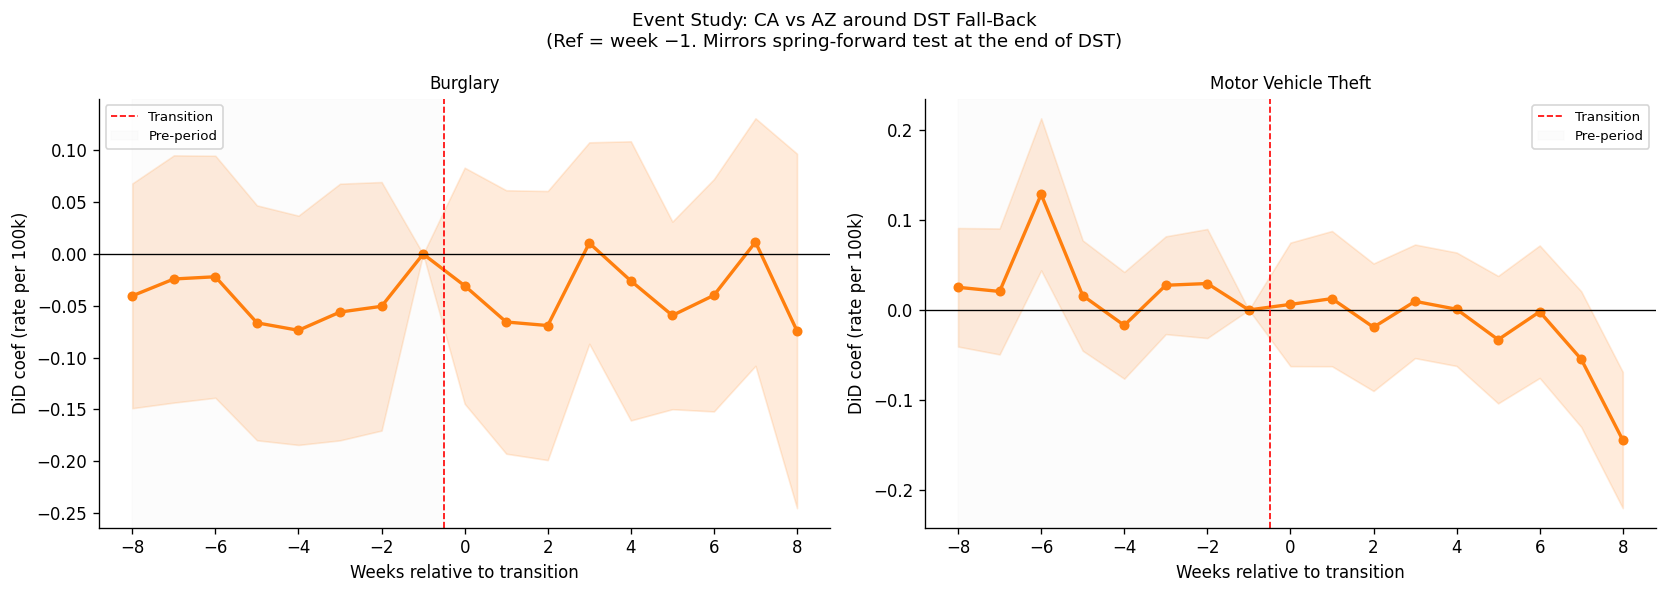

In [22]:
# ── Fall-back event study ─────────────────────────────────────────────────
es_fb = {ct: run_event_study(sample[sample['crime_type'] == ct], 'crime_rate_per_100k',
                              days_col='days_from_dst_end') for ct in CRIMES}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Event Study: CA vs AZ around DST Fall-Back\n'
    '(Ref = week −1. Mirrors spring-forward test at the end of DST)',
    fontsize=11
)
for ax, ct in zip(axes, CRIMES):
    plot_event_study(es_fb[ct], CRIME_LABELS[ct], ax, color='#ff7f0e')
plt.tight_layout()
plt.show()

## Section 2.6 — Narrow-Window Check

Restricts to observations within ±7, ±15, ±21, and ±30 days of the spring-forward date. Within such a short window the season barely changes — only the clocks do — so any estimated effect is more cleanly attributable to DST itself.

In [23]:
window_results = {}
for ct in CRIMES:
    sub = sample[sample['crime_type'] == ct].copy()
    for window in [7, 15, 21, 30]:
        win_sub = sub[sub['days_from_dst_start'].abs() <= window].copy()
        window_results[f'{CRIME_LABELS[ct]} | ±{window}d'] = run_twfe(
            win_sub, 'crime_rate_per_100k', BASE_CONTROLS, time='data_year'
        )

print('=== NARROW-WINDOW RESULTS ===')
print(results_table(window_results).to_string(index=False))
print('\nFE: county + year. SE clustered at county level.')
print('Null result here + null in full-year model → genuine null, not seasonality confound.')

=== NARROW-WINDOW RESULTS ===
             Specification     Coef        SE Sig  p-value            95% CI     N
            Burglary | ±7d  0.03251 (0.02891)       0.2607 [-0.0241, 0.0892]  3150
           Burglary | ±15d  0.01357  (0.0237)       0.5669 [-0.0329, 0.0600]  6510
           Burglary | ±21d  0.02666 (0.01795)       0.1374 [-0.0085, 0.0618]  9030
           Burglary | ±30d  0.01071 (0.02717)       0.6934 [-0.0425, 0.0640] 12810
 Motor Vehicle Theft | ±7d -0.08950 (0.07623)       0.2403 [-0.2389, 0.0599]  3150
Motor Vehicle Theft | ±15d -0.04749 (0.04043)       0.2401 [-0.1267, 0.0318]  6510
Motor Vehicle Theft | ±21d -0.04796  (0.0377)       0.2033 [-0.1219, 0.0259]  9030
Motor Vehicle Theft | ±30d -0.02665 (0.03397)       0.4328 [-0.0932, 0.0399] 12810

FE: county + year. SE clustered at county level.
Null result here + null in full-year model → genuine null, not seasonality confound.


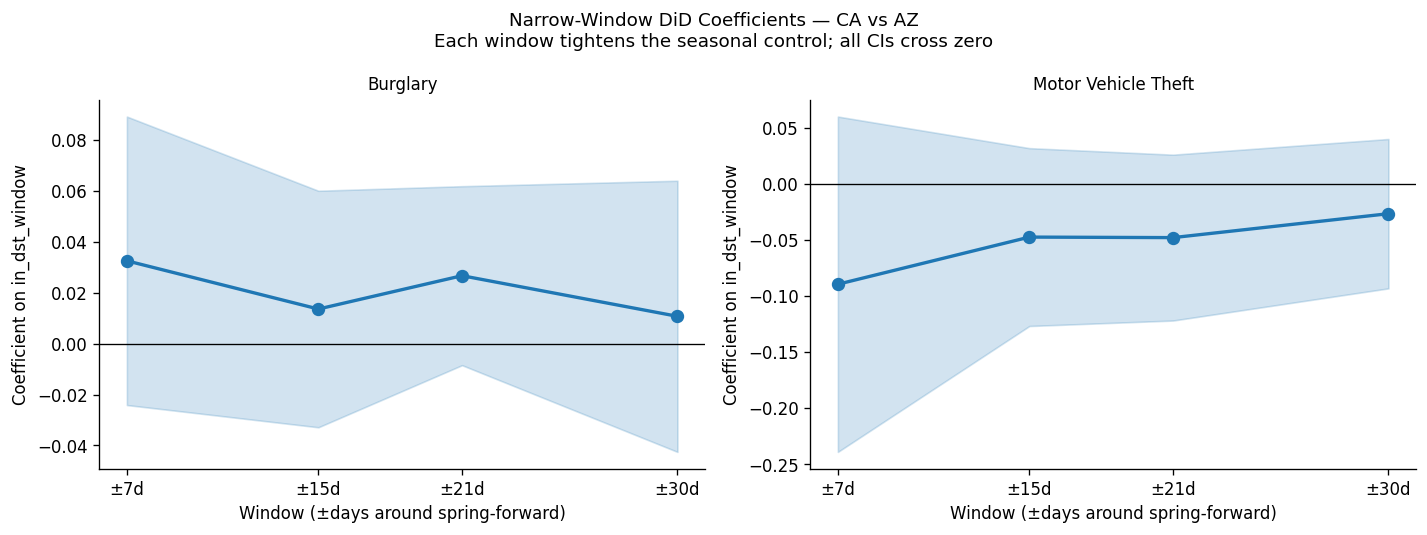

In [24]:
# ── Narrow-window coefficient plot ────────────────────────────────────────
win_tbl = results_table(window_results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle(
    'Narrow-Window DiD Coefficients — CA vs AZ\n'
    'Each window tightens the seasonal control; all CIs cross zero',
    fontsize=11
)

for ax, ct in zip(axes, CRIMES):
    label = CRIME_LABELS[ct]
    rows  = win_tbl[win_tbl['Specification'].str.startswith(label)].copy()
    rows['window'] = [7, 15, 21, 30]

    coefs = rows['Coef'].values
    ci95  = rows['95% CI'].apply(lambda s: float(s.split(', ')[1].rstrip(']')) - float(s.split('[')[1].split(', ')[0])).values / 2

    ax.fill_between(rows['window'], coefs - ci95, coefs + ci95, alpha=0.2, color=STATE_COLORS['CA'])
    ax.plot(rows['window'], coefs, 'o-', color=STATE_COLORS['CA'], lw=2, ms=7)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Window (±days around spring-forward)')
    ax.set_ylabel('Coefficient on in_dst_window')
    ax.set_xticks([7, 15, 21, 30])
    ax.set_xticklabels(['±7d', '±15d', '±21d', '±30d'])

plt.tight_layout()
plt.show()

## Section 2.7 — Robustness Checks

Four checks to test whether the null result is sensitive to specification choices:
1. **Exclude holidays** — removes days with atypical crime patterns unrelated to DST
2. **Weekdays only** — weekends have different crime structures
3. **Placebo** — assigns CA the fake treatment during Nov–Feb (standard time). A real DST effect should not appear here.
4. **Exclude transition fortnight** — drops ±7 days around spring-forward to isolate sustained daylight effect from short-run adjustment effects

In [25]:
robust_results = {}
for ct in CRIMES:
    sub   = sample[sample['crime_type'] == ct].copy()
    label = CRIME_LABELS[ct]

    # R1: Exclude holidays
    robust_results[f'{label} | R1 Exclude holidays'] = run_twfe(
        sub[sub['is_holiday'] == 0], 'crime_rate_per_100k', ['in_dst_window', 'is_weekend']
    )

    # R2: Weekdays only
    robust_results[f'{label} | R2 Weekdays only'] = run_twfe(
        sub[sub['is_weekend'] == 0], 'crime_rate_per_100k', ['in_dst_window', 'is_holiday']
    )

    # R3: Placebo — flip treatment: standard-time months become 'treated' for CA
    sub_p = sub.copy()
    sub_p['in_dst_window'] = (
        (~sub_p['in_dst_window'].astype(bool)) & (sub_p['state'] == 'CA')
    ).astype(float)
    robust_results[f'{label} | R3 Placebo'] = run_twfe(
        sub_p, 'crime_rate_per_100k', BASE_CONTROLS
    )

    # R4: Exclude ±7-day transition fortnight
    robust_results[f'{label} | R4 Excl. ±7d transition'] = run_twfe(
        sub[~sub['days_from_dst_start'].between(-7, 7)].copy(),
        'crime_rate_per_100k', BASE_CONTROLS
    )


# R5: CA+UT as treated vs AZ — coefficient stability with additional treated state
raw_r5 = pd.read_csv(PANEL_PATH, low_memory=False, parse_dates=["incident_date"])
ut_treated_mask = (raw_r5["state"] == "UT") & raw_r5["observes_dst_county"].astype(bool)
ca_treated_mask = (raw_r5["state"] == "CA") & raw_r5["observes_dst_county"].astype(bool)
az_control_mask = raw_r5["is_az_control"].astype(bool) & ~raw_r5["observes_dst_county"].astype(bool)
sample_r5 = raw_r5[ca_treated_mask | ut_treated_mask | az_control_mask].copy()
sample_r5["year_month"] = sample_r5["incident_date"].dt.to_period("M").astype(str)
sample_r5["data_year"]  = sample_r5["incident_date"].dt.year.astype(int)
sample_r5 = sample_r5[sample_r5["crime_type"].isin(CRIMES)].copy()

for ct in CRIMES:
    label = CRIME_LABELS[ct]
    sub_r5 = sample_r5[sample_r5["crime_type"] == ct].copy()
    robust_results[f"{label} | R5 CA+UT treated vs AZ"] = run_twfe(
        sub_r5, "crime_rate_per_100k", BASE_CONTROLS
    )

print('=== ROBUSTNESS CHECKS ===')
print(results_table(robust_results).to_string(index=False))
print('\nFE: county + year-month. SE clustered at county level.')

=== ROBUSTNESS CHECKS ===
                                Specification     Coef        SE Sig  p-value            95% CI      N
               Burglary | R1 Exclude holidays  0.01797 (0.01322)       0.1741 [-0.0079, 0.0439]  73850
                  Burglary | R2 Weekdays only  0.01067 (0.01613)       0.5082 [-0.0209, 0.0423]  54740
                        Burglary | R3 Placebo -0.01665 (0.01351)       0.2178 [-0.0431, 0.0098]  76720
           Burglary | R4 Excl. ±7d transition  0.00726 (0.01624)       0.6549 [-0.0246, 0.0391]  73570
    Motor Vehicle Theft | R1 Exclude holidays -0.00894 (0.02007)       0.6560 [-0.0483, 0.0304]  73850
       Motor Vehicle Theft | R2 Weekdays only -0.01610 (0.02692)       0.5497 [-0.0689, 0.0367]  54740
             Motor Vehicle Theft | R3 Placebo  0.00845 (0.01956)       0.6659 [-0.0299, 0.0468]  76720
Motor Vehicle Theft | R4 Excl. ±7d transition  0.01559 (0.01233)       0.2059 [-0.0086, 0.0398]  73570
            Burglary | R5 CA+UT treated vs AZ  

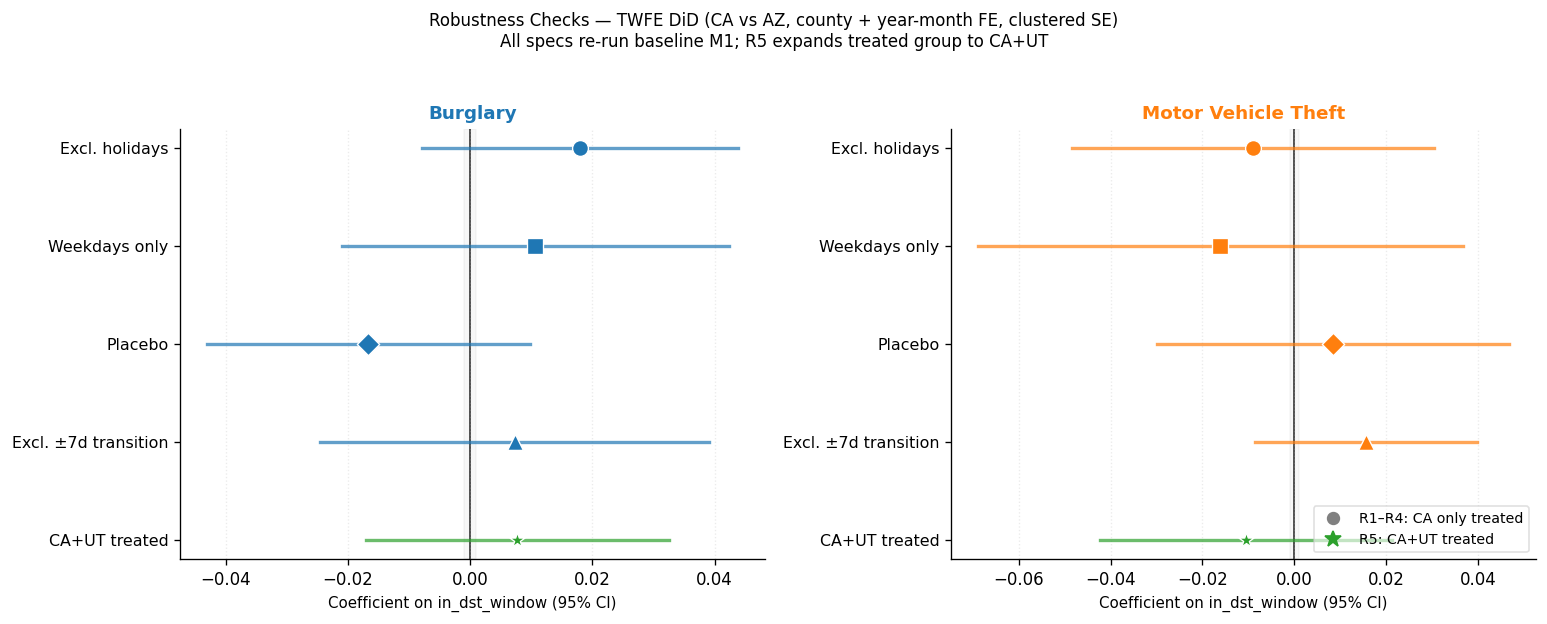

In [26]:
# ── Robustness forest plot ────────────────────────────────────────────────
rob_tbl = results_table(robust_results)

labels = rob_tbl['Specification'].tolist()
coefs = rob_tbl['Coef'].values

ci_str = rob_tbl['95% CI'].str.extract(r'\[(.+), (.+)\]').astype(float)
ci_lo = ci_str[0].values
ci_hi = ci_str[1].values

SPEC_MARKER = {
    'R1': 'o',
    'R2': 's',
    'R3': 'D',
    'R4': '^',
    'R5': '*',
}

SPEC_NOTE = {
    'R1': 'Excl. holidays',
    'R2': 'Weekdays only',
    'R3': 'Placebo',
    'R4': 'Excl. ±7d transition',
    'R5': 'CA+UT treated',
}

def spec_key(label):
    for k in SPEC_MARKER:
        if k + ' ' in label or label.endswith(k):
            return k
    return 'R1'


fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

fig.suptitle(
    'Robustness Checks — TWFE DiD (CA vs AZ, county + year-month FE, clustered SE)\n'
    'All specs re-run baseline M1; R5 expands treated group to CA+UT',
    fontsize=10,
    y=1.03,
)

for ax, ct in zip(axes, CRIMES):
    color = STATE_COLORS['CA'] if ct == 'burglary' else '#ff7f0e'
    ct_label = CRIME_LABELS[ct]

    ct_rows = [
        (l, c, lo, hi)
        for l, c, lo, hi in zip(labels, coefs, ci_lo, ci_hi)
        if ct_label in l
    ]

    y_pos = np.arange(len(ct_rows))[::-1]

    ax.axvline(0, color='#333333', lw=1, zorder=1)
    ax.axvspan(-0.001, 0.001, alpha=0.06, color='gray', zorder=0)

    for yi, (lbl, coef, lo, hi) in enumerate(ct_rows):
        sk = spec_key(lbl)
        marker = SPEC_MARKER.get(sk, 'o')
        is_r5 = sk == 'R5'

        c = '#2ca02c' if is_r5 else color
        y = y_pos[yi]

        ax.plot(
            [lo, hi],
            [y, y],
            color=c,
            lw=2,
            alpha=0.7,
            zorder=2
        )

        ax.scatter(
            coef,
            y,
            color=c,
            s=90,
            marker=marker,
            zorder=3,
            edgecolors='white',
            linewidths=0.8
        )

    short_labels = [
        SPEC_NOTE.get(spec_key(l), l.split('|')[-1].strip())
        for l, *_ in ct_rows
    ]

    ax.set_yticks(y_pos)
    ax.set_yticklabels(short_labels, fontsize=9.5)
    ax.set_xlabel('Coefficient on in_dst_window (95% CI)', fontsize=9)
    ax.set_title(ct_label, fontsize=11, fontweight='bold', color=color)

    ax.grid(axis='x', alpha=0.25, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='gray',
        markersize=7,
        linestyle='None',
        label='R1–R4: CA only treated'
    ),
    Line2D(
        [0], [0],
        marker='*',
        color='#2ca02c',
        markersize=10,
        linestyle='None',
        label='R5: CA+UT treated'
    ),
]

axes[1].legend(
    handles=legend_elements,
    fontsize=8.5,
    loc='lower right',
    framealpha=0.6
)

plt.tight_layout()
plt.show()

## Section 2.8 — Summary

In [27]:
pd.set_option('display.max_colwidth', 55)
pd.set_option('display.float_format', '{:.5f}'.format)

print('=' * 70)
print('CA vs AZ DiD — FULL RESULTS SUMMARY (Florida excluded throughout)')
print('=' * 70)
print('\n--- Stage 1D: Displacement Regression (Triple-Difference) ---')
if did_rows:
    print(pd.DataFrame(did_rows).to_string(index=False))
print('\n--- Stage 2: Main TWFE ---')
print(results_table(results).to_string(index=False))
print('\n--- Stage 2: Narrow-Window ---')
print(results_table(window_results).to_string(index=False))
print('\n--- Stage 2: Robustness ---')
print(results_table(robust_results).to_string(index=False))
print('\n' + '=' * 70)
print('FE: county + year-month (main TWFE), county + year (narrow window).')
print('SE clustered at county level. *** p<0.01  ** p<0.05  * p<0.1')
print('=' * 70)

CA vs AZ DiD — FULL RESULTS SUMMARY (Florida excluded throughout)

--- Stage 1D: Displacement Regression (Triple-Difference) ---
       Bucket     Coef      SE       p Sig
 morning_dark -0.04400 0.06370 0.48950    
evening_light -0.05540 0.06740 0.41100    

--- Stage 2: Main TWFE ---
                    Specification     Coef        SE Sig  p-value            95% CI     N
           Burglary | M1 Baseline  0.01665 (0.01351)      0.21780 [-0.0098, 0.0431] 76720
           Burglary | M2 Log rate  0.00439 (0.00544)      0.41910 [-0.0063, 0.0151] 76720
Motor Vehicle Theft | M1 Baseline -0.00845 (0.01956)      0.66590 [-0.0468, 0.0299] 76720
Motor Vehicle Theft | M2 Log rate  0.00372 (0.00524)      0.47770 [-0.0066, 0.0140] 76720

--- Stage 2: Narrow-Window ---
             Specification     Coef        SE Sig  p-value            95% CI     N
            Burglary | ±7d  0.03251 (0.02891)      0.26070 [-0.0241, 0.0892]  3150
           Burglary | ±15d  0.01357  (0.0237)      0.56690 [-0.032